In [ ]:
%pip install pandas numpy scipy scikit-learn tensorflow xgboost matplotlib seaborn tqdm --proxy http://proxy.istat.it:8080

Note: you may need to restart the kernel to use updated packages.



1. Import essential library for the second attack

In [ ]:
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import re
from pathlib import Path

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.tree import DecisionTreeClassifier

# XGBoost
from xgboost import XGBClassifier

# Utilities
import joblib
from tqdm import tqdm

# Visualization (optional)
import matplotlib.pyplot as plt
import seaborn as sns


2. Complete code for Attack II - with dynamic path

================================================================================
ATTACK MODEL 2: ATTRIBUTE INFERENCE ATTACK PIPELINE
================================================================================

PIPELINE OVERVIEW:
-----------------
This pipeline implements an Attribute Inference Attack that infers the hidden
'diagnosis' class for victim records by exploiting synthetic data (SD) and
labeled training records (TR).

ATTACK SCENARIO:
---------------
The attacker has access to:
1. SYNTHETIC DATASET (SD): 10,000 synthetic samples WITH labels (diagnosis known)
2. TRAINING RECORDS (TR): 8,000 real records (80% of training set) with ALL variables
   including diagnosis (attacker's background knowledge)
3. VICTIM RECORDS (VR): 2,000 real records (20% of training set) where diagnosis
   is HIDDEN - this is what the attacker wants to infer
4. BASELINE RECORDS (BR/M2): 2,000 real records NOT in training set (test set)
   - Used to evaluate if attack truly learned training set patterns

KEY INSIGHT:
-----------
If synthetic data (SD) encodes unit-level information from the training data,
then a model trained on SD + TR can learn relationships that help infer the
hidden attribute in VR. Successful attack = significantly higher accuracy
on VR than on BR (baseline).

ATTACK WORKFLOW - 3 PHASES:
---------------------------

PHASE 1: META-FEATURE EXTRACTION (from TR and SD)
-------------------------------------------------
For each record in TR (with known diagnosis) and each synthetic record in SD:
- Compute distances to each class of synthetic data (class-specific signatures)
- Project into LDA space (discriminant features)
- Extract enhanced features: rank statistics, local consistency, 
  model-based predictions, prototype distances
- Create dataset-level signatures

This produces a rich meta-feature representation (~124 features) that captures
how a record relates to the synthetic and real data spaces.

PHASE 2: TRAIN META-CLASSIFIER (on TR)
--------------------------------------
- Input: Meta-features extracted from TR
- Output: Known diagnosis class (1-4)
- Model: XGBoost multi-class classifier
- Goal: Learn the mapping from meta-features to diagnosis

The intuition: The meta-classifier learns patterns in how training records
interact with synthetic data. These patterns should generalize to VR.

PHASE 3: INFER VICTIM ATTRIBUTES (on VR and BR/M2)
--------------------------------------------------
- Extract same meta-features for VR (diagnosis hidden) and BR/M2
- Apply trained meta-classifier to predict diagnosis
- Evaluate:
  * VR accuracy: Attack success on training set victims
  * BR/M2 accuracy: Baseline/control group (should be lower)
  * Attack advantage = VR accuracy - BR accuracy

EVALUATION METRICS:
------------------
- Accuracy on VR: How well the attack infers hidden diagnosis
- Accuracy on BR/M2: Natural lower bound (no training set information)
- Class-wise accuracy: Performance per diagnosis class
- Improvement over random: (Accuracy - 0.25)
- Generalization gap: VR accuracy - BR accuracy

FEATURE CATEGORIES (124 total):
-------------------------------
1. BASE FEATURES (4 classes × 4 stats = 16)
   - Min, mean, median, std distances to each synthetic class
   
2. LDA FEATURES (13)
   - LDA coordinates (3)
   - Distance and cosine to each class centroid (8)
   - Closest class and confidence (2)
   
3. ENHANCED FEATURES (~80 when enabled)
   - Rank-based (4 per class) - OPTION 1
   - Local consistency (5 per class) - OPTION 2  
   - Model-based predictions (5 per class) - OPTION 4
   - Prototype distances (8 total) - OPTION 5
   
4. CROSS-FEATURES (24 when enabled) - OPTION 3
   - X2 × X2 interactions
   - X2 × demographic interactions

5. DATASET SIGNATURES (10)
   - Overall dataset statistics

6. DOMAIN SHIFT FEATURES (8)
   - Ratios between synthetic and real distances

CONFIGURABLE PARAMETERS:
-----------------------
- PR_VALUE: Privacy risk parameter (controls data perturbation)
- SYNTHETIC_MODEL: Which generator to attack ('xgboost', 'tvae', 'ctgan')
- USE_LDA: Enable LDA projection features
- USE_ENHANCED: Enable advanced features (Options 1,2,4,5)
- USE_CROSS: Enable feature interactions (Option 3)

EXPECTED RESULTS:
----------------
- Success condition: VR accuracy > BR accuracy (significant margin)
- Higher PR_VALUE = more privacy = smaller attack advantage
- Different synthetic models have different vulnerability levels

OUTPUT FILES:
------------
- Attack report (.txt): Complete results and analysis
- Trained model (.pkl): Meta-classifier for reuse
- Meta-features (.csv): For TR, VR, and M2
- Predictions (.csv): Inferred labels for VR and M2
- Confusion matrices (.csv): Class-wise performance

================================================================================

In [ ]:
# ==============================================
# CONFIGURATION - MODIFY HERE!
# ==============================================
SEED = 42
np.random.seed(SEED)

# ==============================================
# DATASET PARAMETERS - MODIFY HERE!
# ==============================================
# Privacy Risk parameter (40, 50, 60, 80, 100, etc.)
PR_VALUE = 100  # <--- MODIFY HERE! (es. 40, 50, 60, 80, 100)

# Synthetic model to use ('xgboost', 'tvae', 'ctgan')
SYNTHETIC_MODEL = 'xgboost'  # <--- MODIFY HERE!

# Feature toggles
USE_LDA = True          # LDA projection features
USE_ENHANCED = False     # Enhanced features (rank, consistency, model, prototype)
USE_CROSS = False        # Cross-features (feature interactions)

# Sampling parameters
SAMPLE_SIZE_SD = 500     # Samples per synthetic class
SAMPLE_SIZE_TR = 1000    # Samples from real training

# ==============================================
# DYNAMIC FILE NAMES - AUTO-GENERATED
# ==============================================
# Base filename patterns
BASE_NAME = f"datasetM10_TH20_RY_PR{PR_VALUE}_4CAT_MISS_X2"

# Real dataset filenames
REAL_FILENAME = f"real_data_{BASE_NAME}.csv"
M2_FILENAME = f"real_data_datasetM2_TH20_RY_PR{PR_VALUE}_4CAT_MISS_X2.csv"

# Synthetic dataset filenames (with model variations)
SYNTHETIC_MODEL_NAMES = {
    'xgboost': ['XGBoost', 'xgboost', 'XGBoost_O0', 'xgboost_O0'],
    'tvae': ['tvae', 'TVAE', 'tvae_O0', 'TVAE_O0'],
    'ctgan': ['ctgan', 'CTGAN', 'ctgan_O0', 'CTGAN_O0']
}

def get_synthetic_filename(model, variant='standard'):
    """
    Generate synthetic filename based on model and PR value.
    
    Parameters:
    - model: 'xgboost', 'tvae', 'ctgan'
    - variant: 'standard' or 'O0'
    """
    model_variants = SYNTHETIC_MODEL_NAMES.get(model.lower(), ['xgboost'])
    
    filenames = []
    for variant_name in model_variants:
        if 'O0' in variant_name:
            filenames.append(f"synthetic_data_{BASE_NAME}_{variant_name}.csv")
        else:
            filenames.append(f"synthetic_data_{BASE_NAME}_{variant_name}.csv")
            filenames.append(f"synthetic_data_{BASE_NAME}_{variant_name}_O0.csv")
    
    return filenames

# ==============================================
# DIRECTORY CONFIGURATION
# ==============================================
username = "donatella.papa"
step1_dir = rf"C:\Users\{username}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step1\output"
step2_dir = rf"C:\Users\{username}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step2\output"

print(f"\nDirectory configuration:")
print(f"  Step1: {step1_dir}")
print(f"  Step2: {step2_dir}")
print(f"  Step1 exists: {os.path.exists(step1_dir)}")
print(f"  Step2 exists: {os.path.exists(step2_dir)}")

print(f"\nDataset configuration:")
print(f"  PR_VALUE: {PR_VALUE}")
print(f"  SYNTHETIC_MODEL: {SYNTHETIC_MODEL}")
print(f"  BASE_NAME: {BASE_NAME}")

# ==============================================
# COLUMNS CONFIGURATION
# ==============================================
selected_columns = [
    'age', 'municipality_residence', 'civil_status', 'gender',
    'occupation', 'physical_activity', 'genetic_predisposition', 'diagnosis'
]

one_hot_columns = [
    'gender', 'civil_status', 'municipality_residence',
    'physical_activity', 'genetic_predisposition', 'age', 'occupation'
]

# ==============================================
# AUTO-DETECT SYNTHETIC FILES
# ==============================================

def find_synthetic_file(model_name, pr_value):
    """
    Automatically find synthetic file for a given model and PR value.
    """
    base_name = f"datasetM10_TH20_RY_PR{pr_value}_4CAT_MISS_X2"
    
    # Patterns based on model name
    model_lower = model_name.lower()
    model_upper = model_name.upper()
    model_capitalized = model_name.capitalize()
    
    base_patterns = [
        f"synthetic_data_{base_name}_{model_lower}",
        f"synthetic_data_{base_name}_{model_upper}",
        f"synthetic_data_{base_name}_{model_capitalized}",
        f"synthetic_data_{base_name}_{model_name}",
    ]
    
    # Variants to try
    variants = []
    for base in base_patterns:
        variants.extend([
            f"{base}.csv",
            f"{base}_O0.csv",
            f"{base}_O0",
            base
        ])
    
    # Special case for XGBoost
    if model_lower == 'xgboost':
        variants.extend([
            f"synthetic_data_{base_name}_XGBoost.csv",
            f"synthetic_data_{base_name}_XGBoost_O0.csv",
            f"synthetic_data_{base_name}_xgboost.csv",
            f"synthetic_data_{base_name}_xgboost_O0.csv",
        ])
    
    # Search for file
    for variant in variants:
        file_path = os.path.join(step2_dir, variant)
        if os.path.exists(file_path):
            return file_path, variant
    
    return None, None

def get_all_synthetic_paths(pr_value):
    """Discover all available synthetic datasets for given PR value."""
    models_to_check = ['xgboost', 'tvae', 'ctgan']
    synthetic_paths = {}
    
    print(f"\n  Scanning for synthetic datasets (PR={pr_value})...")
    for model in models_to_check:
        file_path, filename = find_synthetic_file(model, pr_value)
        if file_path:
            synthetic_paths[f"SY{pr_value}_{model}"] = {
                "dir": step2_dir,
                "file": filename,
                "type": "synthetic",
                "model": model,
                "pr_value": pr_value
            }
            print(f"    {model.upper()}: found -> {filename}")
        else:
            print(f"    {model.upper()}: not found")
    
    return synthetic_paths

# ==============================================
# DATASET PATHS (with auto-detection)
# ==============================================

# Real dataset (dynamic PR)
real_paths = {
    f"RY{PR_VALUE}": {
        "dir": step1_dir,
        "file": REAL_FILENAME,
        "type": "real",
        "pr_value": PR_VALUE
    }
}

# Auto-detect synthetic datasets
synthetic_paths = get_all_synthetic_paths(PR_VALUE)

# Merge all paths
dataset_paths = {**real_paths, **synthetic_paths}

print(f"\nTotal datasets found: {len(dataset_paths)}")
for key in dataset_paths:
    print(f"  - {key}")

# ==============================================
# DATA PREPROCESSING
# ==============================================

def preprocess_dataset(file_path):
    """
    Load and preprocess dataset from CSV file.
    """
    try:
        df = pd.read_csv(file_path)
        
        # Filter selected columns
        df_filtered = df[selected_columns].copy()
        
        # One-hot encode
        df_encoded = pd.get_dummies(df_filtered, columns=one_hot_columns, drop_first=False)
        
        # Extract features and labels
        y = df_encoded['diagnosis'].values
        X = df_encoded.drop('diagnosis', axis=1)
        
        # Convert X to numeric
        for col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')
        
        # Fill NaN with 0
        X = X.fillna(0)
        
        # Convert y to numeric
        y = np.array([int(val) if not pd.isna(val) else 0 for val in y])
        
        return X, y
        
    except Exception as e:
        print(f"Error loading dataset {file_path}: {e}")
        import traceback
        traceback.print_exc()
        return None, None


def load_all_datasets():
    """
    Load all required datasets (real + all synthetic models found).
    """
    print("\n" + "="*80)
    print("LOADING DATASETS")
    print("="*80)
    
    X_train_real = {}
    X_test_real = {}
    y_train_real = {}
    y_test_real = {}
    X_train_synth = {}
    X_test_synth = {}
    y_train_synth = {}
    y_test_synth = {}
    
    for key, params in dataset_paths.items():
        file_path = os.path.join(params["dir"], params["file"])
        print(f"\nLoading {key}...")
        print(f"  Path: {file_path}")
        print(f"  Exists: {os.path.exists(file_path)}")
        
        if os.path.exists(file_path):
            result = preprocess_dataset(file_path)
            if result is not None:
                X, y = result
                
                if X is not None and y is not None and len(X) > 0:
                    X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=0.2, random_state=SEED
                    )
                    
                    if params["type"] == "real":
                        X_train_real[key] = X_train
                        X_test_real[key] = X_test
                        y_train_real[key] = y_train
                        y_test_real[key] = y_test
                        print(f"  ✅ Loaded REAL: {len(X_train)} train, {len(X_test)} test, {X_train.shape[1]} features")
                    else:
                        X_train_synth[key] = X_train
                        X_test_synth[key] = X_test
                        y_train_synth[key] = y_train
                        y_test_synth[key] = y_test
                        print(f"  ✅ Loaded SYNTHETIC ({params.get('model', 'unknown')}): {len(X_train)} train, {len(X_test)} test, {X_train.shape[1]} features")
                else:
                    print(f"  ❌ Empty dataset for {key}")
            else:
                print(f"  ❌ Failed to load {key}")
        else:
            print(f"  ❌ File not found: {file_path}")
    
    return {
        'X_train_real': X_train_real,
        'X_test_real': X_test_real,
        'y_train_real': y_train_real,
        'y_test_real': y_test_real,
        'X_train_synth': X_train_synth,
        'X_test_synth': X_test_synth,
        'y_train_synth': y_train_synth,
        'y_test_synth': y_test_synth
    }


# ==============================================
# DATASET VERIFICATION
# ==============================================

def verify_our_datasets():
    """Verify all required datasets are loaded."""
    
    required_vars = [
        'X_train_real', 'y_train_real',
        'X_test_real', 'y_test_real',
        'X_train_synth', 'y_train_synth'
    ]
    
    missing = [var for var in required_vars if var not in globals()]
    
    if missing:
        print("\n" + "="*80)
        print("ERROR: Missing required datasets")
        print("="*80)
        print("Missing variables:")
        for m in missing:
            print(f"  • {m}")
        return False
    
    if len(X_train_real) == 0 or len(X_train_synth) == 0:
        print("\n" + "="*80)
        print("ERROR: No datasets loaded")
        print("="*80)
        return False
    
    print("\n" + "="*80)
    print("DATASETS VERIFIED - READY FOR ATTACK")
    print("="*80)
    print(f"\nREAL TRAINING DATA: {len(X_train_real)} dataset")
    print(f"REAL TEST DATA: {len(X_test_real)} dataset")
    print(f"SYNTHETIC DATA: {len(X_train_synth)} datasets")
    for key in X_train_synth.keys():
        print(f"  - {key}")
    print(f"\nUsing synthetic model: {SYNTHETIC_MODEL}")
    print(f"Using PR value: {PR_VALUE}")
    
    return True


# ==============================================
# ALIGN FEATURES
# ==============================================

def align_features(X_target, X_reference, dataset_name=""):
    """Align feature sets between different datasets."""
    if X_target is None or X_reference is None:
        return X_target
    
    print(f"\n  Aligning {dataset_name} features to reference...")
    print(f"    Reference features: {len(X_reference.columns)}")
    print(f"    Original features: {X_target.shape[1]}")
    
    if not isinstance(X_target, pd.DataFrame):
        X_target = pd.DataFrame(X_target)
    
    X_aligned = X_target.copy()
    
    missing_cols = []
    for col in X_reference.columns:
        if col not in X_aligned.columns:
            X_aligned[col] = 0
            missing_cols.append(col)
    
    extra_cols = [col for col in X_aligned.columns if col not in X_reference.columns]
    if extra_cols:
        X_aligned = X_aligned.drop(columns=extra_cols)
    
    X_aligned = X_aligned[X_reference.columns]
    
    print(f"    Added {len(missing_cols)} missing columns (filled with 0)")
    print(f"    Removed {len(extra_cols)} extra columns")
    print(f"    Final features: {X_aligned.shape[1]}")
    
    return X_aligned


# ==============================================
# M2 DATASET LOADING AND PROCESSING
# ==============================================

def load_and_process_m2(real_data_reference=None):
    """
    Load M2 dataset with same preprocessing as real dataset.
    Uses dynamic PR value.
    """
    m2_file_path = os.path.join(step1_dir, M2_FILENAME)
    
    print("\n" + "="*80)
    print("LOADING AND PROCESSING M2 DATASET")
    print("="*80)
    print(f"  Path: {m2_file_path}")
    print(f"  Exists: {os.path.exists(m2_file_path)}")
    
    if not os.path.exists(m2_file_path):
        print(f"File not found: {m2_file_path}")
        return None, None
    
    df_m2 = pd.read_csv(m2_file_path)
    print(f"\n1. Loaded M2: {df_m2.shape[0]} rows, {df_m2.shape[1]} columns")
    
    df_filtered = df_m2[selected_columns].copy()
    df_encoded = pd.get_dummies(df_filtered, columns=one_hot_columns, drop_first=False)
    
    if 'diagnosis' not in df_encoded.columns:
        print("ERROR: diagnosis column not found after encoding")
        return None, None
    
    y_m2 = df_encoded['diagnosis'].values
    X_m2 = df_encoded.drop('diagnosis', axis=1)
    
    print(f"\nM2 after encoding:")
    print(f"  Samples: {len(X_m2)}")
    print(f"  Features: {X_m2.shape[1]}")
    
    class_counts = np.bincount(y_m2)
    if len(class_counts) > 4:
        print(f"  Class distribution: {class_counts[1:5]}")
    
    if real_data_reference is not None:
        print("\nAligning with real dataset...")
        
        real_columns = real_data_reference.columns.tolist()
        X_m2_final = pd.DataFrame(index=range(len(X_m2)))
        
        presenti = 0
        mancanti = 0
        
        for col in real_columns:
            if col in X_m2.columns:
                X_m2_final[col] = X_m2[col].values
                presenti += 1
            else:
                X_m2_final[col] = 0
                mancanti += 1
        
        print(f"  Columns present in M2: {presenti}")
        print(f"  Columns added (fill 0): {mancanti}")
        print(f"  Total: {presenti + mancanti}")
        
        return X_m2_final, y_m2
    
    return X_m2, y_m2


def load_our_test_dataset(align_to=None):
    """Load M2 dataset for testing."""
    if align_to is None:
        print("ERROR: reference dataset required for alignment")
        return None, None
    
    X_m2, y_m2 = load_and_process_m2(real_data_reference=align_to)
    
    if X_m2 is not None:
        print(f"\nM2 processed successfully:")
        print(f"  Samples: {len(X_m2)}")
        print(f"  Features: {X_m2.shape[1]}")
    
    return X_m2, y_m2


# ==============================================
# SYNTHETIC DATASET SPLIT BY CLASS
# ==============================================

def split_synthetic_by_class(X_sd, y_sd):
    """Split synthetic dataset into 4 separate datasets by diagnosis class."""
    print(f"\nSplitting synthetic dataset by class...")
    
    if hasattr(y_sd, 'values'):
        y_sd_array = y_sd.values
    else:
        y_sd_array = y_sd
    
    sd_by_class = {}
    
    for class_id in range(1, 5):
        class_mask = (y_sd_array == class_id)
        
        if hasattr(X_sd, 'iloc'):
            X_class = X_sd.iloc[class_mask]
            y_class = y_sd_array[class_mask]
        else:
            X_class = X_sd[class_mask]
            y_class = y_sd_array[class_mask]
            if hasattr(X_sd, 'columns'):
                X_class = pd.DataFrame(X_class, columns=X_sd.columns)
        
        sd_by_class[class_id] = {
            'X': X_class,
            'y': y_class,
            'count': len(X_class) if hasattr(X_class, '__len__') else 0
        }
        
        print(f"  Class {class_id}: {sd_by_class[class_id]['count']} synthetic samples")
    
    return sd_by_class


# ==============================================
# LDA-BASED FEATURES
# ==============================================

def create_lda_projection_space(sd_by_class, n_components=3):
    """Create LDA space using synthetic data to maximize class separation."""
    print("\n" + "="*60)
    print("CREATING LDA PROJECTION SPACE")
    print("="*60)
    
    X_sd_list = []
    y_sd_list = []
    
    for class_id in range(1, 5):
        X_class = sd_by_class[class_id]['X']
        y_class = np.full(len(X_class), class_id)
        
        if hasattr(X_class, 'values'):
            X_sd_list.append(X_class.values)
        else:
            X_sd_list.append(X_class)
        y_sd_list.append(y_class)
    
    X_sd = np.vstack(X_sd_list)
    y_sd = np.concatenate(y_sd_list)
    
    print(f"  Training LDA on {len(X_sd)} synthetic samples")
    print(f"  Original features: {X_sd.shape[1]}")
    
    lda = LDA(n_components=n_components)
    X_sd_lda = lda.fit_transform(X_sd, y_sd)
    
    print(f"  LDA space: {X_sd_lda.shape[1]} dimensions")
    print(f"  Explained variance ratio: {lda.explained_variance_ratio_}")
    
    return {
        'lda': lda,
        'X_sd_lda': X_sd_lda,
        'y_sd': y_sd
    }


def encode_lda_features(x_record, lda_space):
    """
    Project a record into LDA space and compute class proximity features.
    Returns 13 LDA features.
    """
    mf = {}
    
    if hasattr(x_record, 'values'):
        x_record_arr = x_record.values.reshape(1, -1)
    else:
        x_record_arr = np.array(x_record).reshape(1, -1)
    
    try:
        x_lda = lda_space['lda'].transform(x_record_arr)[0]
        
        # LDA coordinates (3 features)
        for i, val in enumerate(x_lda):
            mf[f'lda_dim_{i+1}'] = val
        
        class_dists = []
        for class_id in range(1, 5):
            class_mask = (lda_space['y_sd'] == class_id)
            class_center = np.mean(lda_space['X_sd_lda'][class_mask], axis=0)
            
            # Distance to centroid (4 features)
            dist = np.linalg.norm(x_lda - class_center)
            mf[f'lda_dist_to_class_{class_id}'] = dist
            class_dists.append(dist)
            
            # Cosine similarity (4 features)
            cos_sim = np.dot(x_lda, class_center) / (np.linalg.norm(x_lda) * np.linalg.norm(class_center) + 1e-8)
            mf[f'lda_cos_to_class_{class_id}'] = cos_sim
        
        # Closest class (1 feature)
        closest_class = np.argmin(class_dists) + 1
        mf['lda_closest_class'] = closest_class
        
        # Confidence score (1 feature)
        sorted_dists = np.sort(class_dists)
        mf['lda_confidence'] = 1 - (sorted_dists[0] / (sorted_dists[1] + 1e-8))
        
        # Normalized distances (4 features)
        sum_dists = np.sum(class_dists)
        for i, dist in enumerate(class_dists, 1):
            mf[f'lda_dist_norm_class_{i}'] = dist / (sum_dists + 1e-8)
        
    except Exception as e:
        for i in range(1, 4):
            mf[f'lda_dim_{i}'] = 0
        for i in range(1, 5):
            mf[f'lda_dist_to_class_{i}'] = 999
            mf[f'lda_cos_to_class_{i}'] = 0
        mf['lda_closest_class'] = 1
        mf['lda_confidence'] = 0
        for i in range(1, 5):
            mf[f'lda_dist_norm_class_{i}'] = 0.25
    
    return pd.Series(mf)


# ==============================================
# ENHANCED FEATURE FUNCTIONS (Options 1-5)
# ==============================================

def compute_rank_features(distances, prefix=""):
    """OPTION 1: Rank-based features (4 features per group)"""
    rank_features = {}
    
    if len(distances) == 0:
        return rank_features
    
    sorted_dists = np.sort(distances)
    
    min_dist = np.min(distances)
    rank_min = np.searchsorted(sorted_dists, min_dist)
    rank_features[f'{prefix}rank_min'] = rank_min / len(distances)
    
    mean_dist = np.mean(distances)
    rank_mean = np.searchsorted(sorted_dists, mean_dist)
    rank_features[f'{prefix}rank_mean'] = rank_mean / len(distances)
    
    median_dist = np.median(distances)
    rank_median = np.searchsorted(sorted_dists, median_dist)
    rank_features[f'{prefix}rank_median'] = rank_median / len(distances)
    
    return rank_features


def compute_consistency_features(nearest_labels, prefix=""):
    """OPTION 2: Local consistency features (5 features per group)"""
    consistency = {}
    
    if len(nearest_labels) == 0:
        return consistency
    
    k = len(nearest_labels)
    labels_arr = np.array(nearest_labels)
    
    # Label variance
    consistency[f'{prefix}label_var'] = np.var(labels_arr)
    
    # Class changes between consecutive neighbors
    changes = np.sum(labels_arr[:-1] != labels_arr[1:])
    consistency[f'{prefix}class_changes'] = changes / k
    
    # Majority class agreement
    unique, counts = np.unique(labels_arr, return_counts=True)
    majority_idx = np.argmax(counts)
    majority = unique[majority_idx]
    agreement = counts[majority_idx] / k
    consistency[f'{prefix}majority_agreement'] = agreement
    
    # Longest run of majority class
    runs = 0
    current_run = 0
    for label in labels_arr:
        if label == majority:
            current_run += 1
        else:
            runs = max(runs, current_run)
            current_run = 0
    runs = max(runs, current_run)
    consistency[f'{prefix}majority_run'] = runs / k
    
    # Entropy
    probs = counts / k
    entropy = -np.sum(probs * np.log2(probs + 1e-8))
    consistency[f'{prefix}entropy'] = entropy
    
    return consistency


def compute_model_based_features(x_record, X_local, y_local, prefix=""):
    """OPTION 4: Model-based features (5 features per group)"""
    model_features = {}
    
    if len(X_local) < 10 or len(np.unique(y_local)) < 2:
        model_features[f'{prefix}tree_confidence'] = 0.25
        model_features[f'{prefix}tree_margin'] = 0
        model_features[f'{prefix}tree_entropy'] = 2.0
        return model_features
    
    dt = DecisionTreeClassifier(max_depth=2, min_samples_split=3, random_state=42)
    dt.fit(X_local, y_local)
    
    if hasattr(x_record, 'values'):
        x_arr = x_record.values.reshape(1, -1)
    else:
        x_arr = np.array(x_record).reshape(1, -1)
    
    probs = dt.predict_proba(x_arr)[0]
    
    full_probs = np.zeros(4)
    for i, p in enumerate(probs):
        if i < 4:
            full_probs[i] = p
    
    model_features[f'{prefix}tree_confidence'] = np.max(full_probs)
    
    sorted_probs = np.sort(full_probs)[::-1]
    if len(sorted_probs) > 1:
        model_features[f'{prefix}tree_margin'] = sorted_probs[0] - sorted_probs[1]
    else:
        model_features[f'{prefix}tree_margin'] = sorted_probs[0]
    
    non_zero = full_probs[full_probs > 0]
    if len(non_zero) > 0:
        entropy = -np.sum(non_zero * np.log2(non_zero))
    else:
        entropy = 2.0
    model_features[f'{prefix}tree_entropy'] = entropy
    
    return model_features


def compute_prototype_features(x_record, sd_by_class, X_tr, y_tr, prefix=""):
    """OPTION 5: Prototype-based features (8 features)"""
    prototype_features = {}
    
    if hasattr(x_record, 'values'):
        x_arr = x_record.values.flatten().reshape(1, -1)
    else:
        x_arr = np.array(x_record).flatten().reshape(1, -1)
    
    # Synthetic prototypes
    for class_id in range(1, 5):
        X_class = sd_by_class[class_id]['X']
        if len(X_class) > 10:
            if hasattr(X_class, 'values'):
                prototype = X_class.mean(axis=0).values.reshape(1, -1)
            else:
                prototype = X_class.mean(axis=0).reshape(1, -1)
            
            dist = euclidean_distances(x_arr, prototype)[0, 0]
            prototype_features[f'{prefix}sd_proto_class_{class_id}'] = dist
        else:
            prototype_features[f'{prefix}sd_proto_class_{class_id}'] = -1
    
    # Real prototypes (from TR)
    for class_id in range(1, 5):
        class_mask = (y_tr == class_id)
        if np.sum(class_mask) > 10:
            if hasattr(X_tr, 'iloc'):
                X_class = X_tr[class_mask]
                if hasattr(X_class, 'values'):
                    prototype = X_class.mean(axis=0).values.reshape(1, -1)
                else:
                    prototype = X_class.mean(axis=0).reshape(1, -1)
            else:
                X_class = X_tr[class_mask]
                prototype = X_class.mean(axis=0).reshape(1, -1)
            
            dist = euclidean_distances(x_arr, prototype)[0, 0]
            prototype_features[f'{prefix}tr_proto_class_{class_id}'] = dist
        else:
            prototype_features[f'{prefix}tr_proto_class_{class_id}'] = -1
    
    return prototype_features


def add_cross_features_to_dataset(X_meta, X_original, dataset_name=""):
    """OPTION 3: Add cross-features (interactions) at dataset level."""
    print(f"  Adding cross-features for {dataset_name}...")
    
    cross_df = pd.DataFrame(index=X_meta.index)
    
    if hasattr(X_original, 'columns'):
        x2_cols = [c for c in X_original.columns 
                   if 'physical_activity' in c or 'genetic_predisposition' in c]
        
        demo_cols = [c for c in X_original.columns 
                     if 'age' in c or 'gender' in c or 'civil_status' in c or 'occupation' in c]
        
        # X2 × X2 interactions (limited to 15)
        count = 0
        for i, col1 in enumerate(x2_cols[:5]):
            for col2 in x2_cols[i+1:5]:
                if count < 15:
                    cross_df[f'cross_x2_{i}_{count}'] = (X_original[col1] * X_original[col2]).astype(float)
                    count += 1
        
        # X2 × demographic interactions (limited to 9)
        count = 0
        for col1 in x2_cols[:3]:
            for col2 in demo_cols[:3]:
                if count < 9:
                    base_name = col1.split('_')[0] if '_' in col1 else col1
                    cross_df[f'cross_{base_name}_demo_{count}'] = (X_original[col1] * X_original[col2]).astype(float)
                    count += 1
    
    if cross_df.shape[1] > 0:
        for col in cross_df.columns:
            if cross_df[col].dtype == 'object':
                cross_df[col] = cross_df[col].astype(float)
        
        X_meta_extended = pd.concat([X_meta, cross_df], axis=1)
        print(f"    Added {cross_df.shape[1]} cross-features")
        return X_meta_extended
    else:
        return X_meta


def extract_dataset_signature(X, y, name=""):
    """Extract statistical fingerprint of a dataset (10 features)."""
    mf = {}
    
    mf['n_samples'] = len(X)
    mf['n_features'] = X.shape[1] if hasattr(X, 'shape') else 0
    
    unique, counts = np.unique(y, return_counts=True)
    for i in range(1, 5):
        idx = np.where(unique == i)[0]
        count = counts[idx[0]] if len(idx) > 0 else 0
        mf[f'class_{i}_count'] = count
        mf[f'class_{i}_ratio'] = count/len(y) if len(y) > 0 else 0
    
    return pd.Series(mf)


# ==============================================
# COMPLETE META-FEATURE ENCODING (124 FEATURES)
# ==============================================

def encode_record_meta_features_complete(x_record, sd_by_class, X_tr, y_tr, 
                                         lda_space=None, use_enhanced=True, seed=None):
    """Complete meta-feature extraction with all 124 features."""
    mf = {}
    
    if not isinstance(x_record, pd.DataFrame):
        if hasattr(x_record, 'values'):
            x_record_df = pd.DataFrame([x_record.values], 
                                      columns=x_record.index if hasattr(x_record, 'index') else None)
        else:
            x_record_df = pd.DataFrame([x_record])
    else:
        x_record_df = x_record
    
    if seed is not None:
        np.random.seed(seed)
    
    # === LDA FEATURES (13) ===
    if lda_space is not None:
        lda_features = encode_lda_features(x_record, lda_space)
        mf.update(lda_features)
    
    # === CLASS-SPECIFIC SYNTHETIC SPACE ANALYSIS ===
    all_class_dists = []
    
    for class_id in range(1, 5):
        class_data = sd_by_class[class_id]
        X_class = class_data['X']
        y_class = class_data['y']
        
        if len(X_class) == 0:
            mf[f'sd_class_{class_id}_dist_min'] = 999
            mf[f'sd_class_{class_id}_dist_mean'] = 999
            mf[f'sd_class_{class_id}_dist_median'] = 999
            mf[f'sd_class_{class_id}_dist_std'] = 0
            all_class_dists.append(999)
            continue
        
        sample_size = min(SAMPLE_SIZE_SD, len(X_class))
        
        if hasattr(X_class, 'iloc'):
            class_indices = np.random.choice(len(X_class), sample_size, replace=False)
            class_sample = X_class.iloc[class_indices]
            if hasattr(y_class, 'iloc'):
                y_sample = y_class.iloc[class_indices]
            else:
                y_sample = y_class[class_indices]
        else:
            class_indices = np.random.choice(len(X_class), sample_size, replace=False)
            class_sample = X_class[class_indices]
            y_sample = y_class[class_indices]
            if hasattr(X_class, 'columns'):
                class_sample = pd.DataFrame(class_sample, columns=X_class.columns)
        
        distances = euclidean_distances(x_record_df, class_sample)[0]
        min_dist = np.min(distances)
        all_class_dists.append(min_dist)
        
        # Basic statistics (4 features per class = 16)
        mf[f'sd_class_{class_id}_dist_min'] = min_dist
        mf[f'sd_class_{class_id}_dist_mean'] = np.mean(distances)
        mf[f'sd_class_{class_id}_dist_median'] = np.median(distances)
        mf[f'sd_class_{class_id}_dist_std'] = np.std(distances)
        mf[f'sd_class_{class_id}_has_examples'] = 1
        
        k = min(15, len(class_sample))
        nearest_idx = np.argsort(distances)[:k]
        
        if hasattr(y_sample, 'iloc'):
            nearest_labels = y_sample.iloc[nearest_idx]
        else:
            nearest_labels = y_sample[nearest_idx]
        
        if hasattr(nearest_labels, 'values'):
            nearest_labels = nearest_labels.values
        
        # Neighbor label distributions (4 features per class = 16)
        for i in range(1, 5):
            mf[f'sd_class_{class_id}_neigh_class_{i}'] = np.sum(nearest_labels == i) / k
        
        # === ENHANCED FEATURES (if enabled) ===
        if use_enhanced:
            # Option 1: Rank-based (4 features)
            rank_features = compute_rank_features(distances, f'sd_class_{class_id}_')
            mf.update(rank_features)
            
            # Option 2: Consistency (5 features)
            if len(nearest_labels) > 0:
                cons_features = compute_consistency_features(nearest_labels, f'sd_class_{class_id}_')
                mf.update(cons_features)
            
            # Option 4: Model-based (5 features)
            if len(class_sample) >= 10:
                if hasattr(class_sample, 'values'):
                    X_local = class_sample.iloc[nearest_idx].values
                else:
                    X_local = class_sample[nearest_idx]
                
                model_features = compute_model_based_features(
                    x_record_df, X_local, nearest_labels, 
                    f'sd_class_{class_id}_'
                )
                mf.update(model_features)
    
    # === COMPARATIVE METRICS BETWEEN CLASSES (3 features) ===
    all_class_dists = [mf.get(f'sd_class_{i}_dist_min', 999) for i in range(1, 5)]
    
    closest_class = np.argmin(all_class_dists) + 1
    sorted_indices = np.argsort(all_class_dists)
    second_closest = sorted_indices[1] + 1
    
    mf['sd_closest_class'] = closest_class
    mf['sd_second_closest_class'] = second_closest
    mf['sd_dist_ratio_closest_second'] = all_class_dists[closest_class-1] / (all_class_dists[second_closest-1] + 1e-8)
    
    # === REAL SPACE BEHAVIOR (9 + enhanced) ===
    try:
        sample_size_tr = min(SAMPLE_SIZE_TR, len(X_tr))
        
        if hasattr(X_tr, 'iloc'):
            tr_indices = np.random.choice(len(X_tr), sample_size_tr, replace=False)
            tr_sample = X_tr.iloc[tr_indices]
            if hasattr(y_tr, 'iloc'):
                y_tr_sample = y_tr.iloc[tr_indices]
            else:
                y_tr_sample = y_tr[tr_indices]
        else:
            tr_indices = np.random.choice(len(X_tr), sample_size_tr, replace=False)
            tr_sample = X_tr[tr_indices]
            y_tr_sample = y_tr[tr_indices]
            if hasattr(X_tr, 'columns'):
                tr_sample = pd.DataFrame(tr_sample, columns=X_tr.columns)
        
        distances_tr = euclidean_distances(x_record_df, tr_sample)[0]
        
        # Basic statistics (4 features)
        mf['tr_dist_min'] = np.min(distances_tr)
        mf['tr_dist_mean'] = np.mean(distances_tr)
        mf['tr_dist_median'] = np.median(distances_tr)
        mf['tr_dist_std'] = np.std(distances_tr)
        
        k = min(15, len(tr_sample))
        nearest_idx_tr = np.argsort(distances_tr)[:k]
        
        if hasattr(y_tr_sample, 'iloc'):
            nearest_labels_tr = y_tr_sample.iloc[nearest_idx_tr]
        else:
            nearest_labels_tr = y_tr_sample[nearest_idx_tr]
        
        if hasattr(nearest_labels_tr, 'values'):
            nearest_labels_tr = nearest_labels_tr.values
        
        # Class proportions in neighborhood (4 features)
        for i in range(1, 5):
            mf[f'tr_neigh_class_{i}'] = np.sum(nearest_labels_tr == i) / k
        
        # Majority class (1 feature)
        mf['tr_majority_class'] = np.bincount(nearest_labels_tr.astype(int)).argmax() if len(nearest_labels_tr) > 0 else 0
        
        # === ENHANCED FEATURES FOR REAL SPACE ===
        if use_enhanced:
            # Option 1: Rank-based (4 features)
            rank_features_tr = compute_rank_features(distances_tr, 'tr_')
            mf.update(rank_features_tr)
            
            # Option 2: Consistency (5 features)
            if len(nearest_labels_tr) > 0:
                cons_features_tr = compute_consistency_features(nearest_labels_tr, 'tr_')
                mf.update(cons_features_tr)
            
            # Option 4: Model-based (5 features)
            if len(tr_sample) >= 10:
                if hasattr(tr_sample, 'values'):
                    X_local_tr = tr_sample.iloc[nearest_idx_tr].values
                else:
                    X_local_tr = tr_sample[nearest_idx_tr]
                
                model_features_tr = compute_model_based_features(
                    x_record_df, X_local_tr, nearest_labels_tr, 'tr_'
                )
                mf.update(model_features_tr)
        
    except Exception as e:
        mf['tr_dist_min'] = 0
        mf['tr_dist_mean'] = 0
        mf['tr_dist_median'] = 0
        mf['tr_dist_std'] = 0
        for i in range(1, 5):
            mf[f'tr_neigh_class_{i}'] = 0.25
        mf['tr_majority_class'] = 1
    
    # === DOMAIN SHIFT FEATURES (8 features) ===
    for class_id in range(1, 5):
        mf[f'ratio_sd_class_{class_id}_to_real'] = (
            mf.get(f'sd_class_{class_id}_dist_min', 999) / (mf['tr_dist_mean'] + 1e-8)
        )
        
        mf[f'closer_to_sd_class_{class_id}_than_real'] = (
            1 if mf.get(f'sd_class_{class_id}_dist_min', 999) < mf['tr_dist_min'] else 0
        )
    
    # === OPTION 5: PROTOTYPE-BASED FEATURES (8 features) ===
    if use_enhanced:
        proto_features = compute_prototype_features(x_record_df, sd_by_class, X_tr, y_tr)
        mf.update(proto_features)
    
    return pd.Series(mf)


def extract_meta_features_dataset_complete(X, y, sd_by_class, X_tr, y_tr,
                                           lda_space=None, use_enhanced=True,
                                           dataset_signature=None, dataset_name=""):
    """Extract complete meta-features for all records in a dataset."""
    print(f"\nExtracting COMPLETE meta-features for {dataset_name} ({len(X)} samples)...")
    if use_enhanced:
        print(f"  Enhanced features: ENABLED (Options 1-5)")
    else:
        print(f"  Enhanced features: DISABLED (base only)")
    
    X_meta_list = []
    y_list = [] if y is not None else None
    
    for i in range(len(X)):
        if i % 1000 == 0 and i > 0:
            print(f"  Processed {i}/{len(X)} records")
        
        if hasattr(X, 'iloc'):
            x_record = X.iloc[i:i+1]
        else:
            x_record = X[i:i+1]
        
        record_meta = encode_record_meta_features_complete(
            x_record, sd_by_class, X_tr, y_tr,
            lda_space=lda_space,
            use_enhanced=use_enhanced,
            seed=SEED + i
        )
        
        if dataset_signature is not None:
            for feat_name, feat_value in dataset_signature.items():
                record_meta[f'dataset_{feat_name}'] = feat_value
        
        X_meta_list.append(record_meta)
        
        if y is not None:
            if hasattr(y, 'iloc'):
                y_list.append(y.iloc[i])
            else:
                y_list.append(y[i])
    
    X_meta = pd.DataFrame(X_meta_list)
    y_array = np.array(y_list) if y_list is not None else None
    
    print(f"  Extracted {X_meta.shape[1]} meta-features")
    
    if y_array is not None:
        print(f"  Labels shape: {y_array.shape}")
    
    return X_meta, y_array


# ==============================================
# BUILD ATTACK DATASET
# ==============================================
def build_attack_dataset_class_specific():
    """
    Build attack dataset with class-specific synthetic split.
    Uses SYNTHETIC_MODEL to select which synthetic model to use.
    """
    print("\n" + "="*80)
    print("BUILDING ATTACK DATASET - CLASS-SPECIFIC VERSION")
    print("="*80)
    
    # TR: Real training data
    real_key = f"RY{PR_VALUE}"
    if real_key not in X_train_real:
        if len(X_train_real) > 0:
            real_key = list(X_train_real.keys())[0]
            print(f"WARNING: {real_key} not found, using {real_key}")
        else:
            print("ERROR: No real training data available")
            return None
    
    X_tr = X_train_real[real_key]
    y_tr = y_train_real[real_key]
    
    print(f"\n1. TR (Real Training Data):")
    print(f"   File: {real_key}")
    print(f"   Samples: {len(X_tr)}")
    print(f"   Features: {X_tr.shape[1] if hasattr(X_tr, 'shape') else 'N/A'}")
    print(f"   Class distribution: {np.bincount(y_tr)[1:5]}")
    
    reference_columns = X_tr.columns if hasattr(X_tr, 'columns') else None
    
    # VR: Victim Records
    if real_key not in X_test_real:
        print(f"ERROR: {real_key} not found in X_test_real!")
        return None
    
    X_vr = X_test_real[real_key]
    y_vr_true = y_test_real[real_key]
    
    print(f"\n2. VR (Victim Records):")
    print(f"   Samples: {len(X_vr)}")
    print(f"   Class distribution: {np.bincount(y_vr_true)[1:5]}")
    
    # SD: Synthetic Data - Select based on SYNTHETIC_MODEL
    print(f"\n3. SD (Synthetic Data):")
    print(f"   Available synthetic keys: {list(X_train_synth.keys())}")
    
    synth_key = None
    
    # Search for specific model with current PR value
    target_key = f"SY{PR_VALUE}_{SYNTHETIC_MODEL}"
    if target_key in X_train_synth:
        synth_key = target_key
        print(f"   Found matching model: {synth_key}")
    else:
        # Try to find by model name (case insensitive)
        for key in X_train_synth.keys():
            if SYNTHETIC_MODEL.lower() in key.lower():
                synth_key = key
                print(f"   Found matching model: {synth_key}")
                break
    
    # If not found, try fallback
    if synth_key is None and X_train_synth:
        synth_key = list(X_train_synth.keys())[0]
        print(f"   WARNING: {SYNTHETIC_MODEL} not found. Using fallback: {synth_key}")
    
    if synth_key is None:
        print("   ERROR: No synthetic data available!")
        return None
    
    X_sd_raw = X_train_synth[synth_key]
    y_sd = y_train_synth[synth_key]
    
    print(f"   Using: {synth_key}")
    print(f"   Raw samples: {len(X_sd_raw) if hasattr(X_sd_raw, '__len__') else 'N/A'}")
    
    if reference_columns is not None and hasattr(X_sd_raw, 'columns'):
        X_sd = align_features(X_sd_raw, X_tr, dataset_name="SD")
    else:
        X_sd = X_sd_raw
    
    sd_by_class = split_synthetic_by_class(X_sd, y_sd)
    
    # TEST: M2 Dataset
    X_test, y_test = load_our_test_dataset(align_to=X_tr if reference_columns is not None else None)
    
    print("\n" + "="*80)
    print("ATTACK DATASET READY")
    print("="*80)
    print(f"TR:   {len(X_tr)} samples (labels KNOWN)")
    print(f"VR:   {len(X_vr)} samples (labels HIDDEN) - TARGET")
    print(f"SD:   {len(X_sd)} total synthetic samples")
    for class_id in range(1, 5):
        print(f"      Class {class_id}: {sd_by_class[class_id]['count']} samples")
    if X_test is not None:
        print(f"TEST: {len(X_test)} samples (M2 independent)")
    
    return {
        'X_tr': X_tr, 'y_tr': y_tr,
        'X_vr': X_vr, 'y_vr_true': y_vr_true,
        'sd_by_class': sd_by_class,
        'X_test': X_test, 'y_test': y_test,
        'real_key': real_key,
        'synth_key': synth_key,
        'reference_columns': reference_columns
    }


# ==============================================
# EXECUTE COMPLETE ATTACK
# ==============================================

def run_attack2_complete(use_lda=True, use_enhanced=True, use_cross=True):
    """Execute Attack #2 with all features."""
    
    print("\n" + "="*80)
    print("ATTACK #2 - COMPLETE ENHANCED VERSION")
    print("="*80)
    print(f"\nFEATURE CONFIGURATION:")
    print(f"  • Class-specific synthetic distances: YES (base)")
    print(f"  • LDA features: {'YES' if use_lda else 'NO'}")
    print(f"  • Enhanced options (rank, consistency, model, prototype): {'YES' if use_enhanced else 'NO'}")
    print(f"  • Cross-features (Option 3): {'YES' if use_cross else 'NO'}")
    
    if not verify_our_datasets():
        return None
    
    # STEP 1: Prepare datasets
    print("\n1. PREPARING ATTACK DATASETS...")
    data = build_attack_dataset_class_specific()
    if data is None:
        return None
    
    # STEP 2: Create LDA space if requested
    lda_space = None
    if use_lda:
        print("\n2. CREATING LDA PROJECTION SPACE...")
        lda_space = create_lda_projection_space(data['sd_by_class'])
    
    # STEP 3: Extract dataset-level signatures
    print("\n3. EXTRACTING DATASET-LEVEL SIGNATURES...")
    X_sd_full_list = []
    for c in range(1, 5):
        X_c = data['sd_by_class'][c]['X']
        if hasattr(X_c, 'values'):
            X_sd_full_list.append(X_c.values)
        else:
            X_sd_full_list.append(X_c)
    
    X_sd_full = np.vstack(X_sd_full_list) if all([hasattr(x, 'shape') for x in X_sd_full_list]) else None
    y_sd_full = np.concatenate([data['sd_by_class'][c]['y'] for c in range(1, 5)])
    
    if X_sd_full is not None:
        mf_sd = extract_dataset_signature(X_sd_full, y_sd_full, "SD")
    else:
        mf_sd = pd.Series()
    
    mf_tr = extract_dataset_signature(data['X_tr'], data['y_tr'], "TR")
    dataset_signature = pd.concat([mf_sd, mf_tr]) if len(mf_sd) > 0 else mf_tr
    print(f"   Dataset signature: {len(dataset_signature)} features")
    
    # STEP 4: Extract meta-features from TR
    print("\n4. EXTRACTING META-FEATURES FROM TR (TRAINING)...")
    X_meta_tr, y_meta_tr = extract_meta_features_dataset_complete(
        data['X_tr'], data['y_tr'],
        data['sd_by_class'],
        data['X_tr'], data['y_tr'],
        lda_space=lda_space,
        use_enhanced=use_enhanced,
        dataset_signature=dataset_signature,
        dataset_name="TR"
    )
    
    # Add cross-features if requested
    if use_cross:
        X_meta_tr = add_cross_features_to_dataset(X_meta_tr, data['X_tr'], "TR")
    
    print(f"\n  Total meta-features: {X_meta_tr.shape[1]}")
    
    # STEP 5: Train meta-classifier
    print("\n5. TRAINING META-CLASSIFIER...")
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_meta_tr, y_meta_tr - 1,
        test_size=0.2,
        random_state=SEED,
        stratify=y_meta_tr
    )
    
    meta_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        objective='multi:softmax',
        num_class=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=SEED,
        use_label_encoder=False,
        eval_metric='mlogloss',
        verbosity=0
    )
    
    meta_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    val_pred = meta_model.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_pred)
    print(f"\n  Validation accuracy on TR: {val_accuracy:.4f}")
    
    # Feature importance analysis
    if hasattr(meta_model, 'feature_importances_'):
        importance_df = pd.DataFrame({
            'feature': X_meta_tr.columns,
            'importance': meta_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\n  Top 10 most important features:")
        for i, row in importance_df.head(10).iterrows():
            print(f"    {i+1:2d}. {row['feature'][:50]}: {row['importance']:.4f}")
    else:
        importance_df = None
    
    # STEP 6: Extract meta-features from VR
    print("\n6. EXTRACTING META-FEATURES FROM VR...")
    X_meta_vr, _ = extract_meta_features_dataset_complete(
        data['X_vr'], None,
        data['sd_by_class'],
        data['X_tr'], data['y_tr'],
        lda_space=lda_space,
        use_enhanced=use_enhanced,
        dataset_signature=dataset_signature,
        dataset_name="VR"
    )
    
    if use_cross:
        X_meta_vr = add_cross_features_to_dataset(X_meta_vr, data['X_vr'], "VR")
    
    # STEP 7: Predict VR labels
    print("\n7. PREDICTING VR LABELS...")
    y_pred = meta_model.predict(X_meta_vr) + 1
    
    # STEP 8: Evaluate attack
    attack_accuracy = accuracy_score(data['y_vr_true'], y_pred)
    baseline = 0.25
    improvement = attack_accuracy - baseline
    
    cm = confusion_matrix(data['y_vr_true'], y_pred)
    
    print(f"\n{'='*60}")
    print("ATTACK RESULTS")
    print(f"{'='*60}")
    print(f"  Attack accuracy on VR: {attack_accuracy:.4f}")
    print(f"  Random baseline: {baseline:.4f}")
    print(f"  Improvement: {improvement:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    
    # Class-wise accuracy
    print(f"\nClass-wise accuracy:")
    vr_class_wise = []
    for i in range(4):
        correct = cm[i, i]
        total = np.sum(cm[i, :])
        class_acc = correct / total
        vr_class_wise.append(class_acc)
        print(f"  Class {i+1}: {class_acc:.3f} ({correct}/{total})")
    
    # STEP 9: Test on M2
    test_accuracy = None
    cm_m2 = None
    m2_class_wise = None
    
    if data['X_test'] is not None and data['y_test'] is not None:
        print(f"\n{'='*60}")
        print("INDEPENDENT TEST ON M2 DATASET")
        print(f"{'='*60}")
        
        X_meta_test, y_meta_test = extract_meta_features_dataset_complete(
            data['X_test'], data['y_test'],
            data['sd_by_class'],
            data['X_tr'], data['y_tr'],
            lda_space=lda_space,
            use_enhanced=use_enhanced,
            dataset_signature=dataset_signature,
            dataset_name="M2"
        )
        
        if use_cross:
            X_meta_test = add_cross_features_to_dataset(X_meta_test, data['X_test'], "M2")
        
        y_test_pred = meta_model.predict(X_meta_test) + 1
        test_accuracy = accuracy_score(data['y_test'], y_test_pred)
        
        cm_m2 = confusion_matrix(data['y_test'], y_test_pred)
        
        print(f"\n  Test accuracy on M2: {test_accuracy:.4f}")
        print(f"  Generalization gap: {attack_accuracy - test_accuracy:.4f}")
        print(f"\nM2 Confusion Matrix:")
        print(cm_m2)
        
        print(f"\nM2 Class-wise accuracy:")
        m2_class_wise = []
        for i in range(4):
            correct = cm_m2[i, i]
            total = np.sum(cm_m2[i, :])
            class_acc = correct / total
            m2_class_wise.append(class_acc)
            print(f"  Class {i+1}: {class_acc:.3f} ({correct}/{total})")
    
    # Create results dictionary
    results = {
        'success': True,
        'attack_accuracy': attack_accuracy,
        'baseline': baseline,
        'improvement': improvement,
        'test_accuracy': test_accuracy,
        'val_accuracy': val_accuracy,
        'meta_model': meta_model,
        'X_meta_tr': X_meta_tr,
        'X_meta_vr': X_meta_vr,
        'y_pred': y_pred,
        'y_true': data['y_vr_true'],
        'data': data,
        'feature_importance': importance_df,
        'dataset_signature': dataset_signature,
        'confusion_matrix': cm,
        'vr_class_wise': vr_class_wise,
        'n_features': X_meta_tr.shape[1] if X_meta_tr is not None else 0,
        'config': {
            'use_lda': use_lda,
            'use_enhanced': use_enhanced,
            'use_cross': use_cross
        },
        'pr_value': PR_VALUE,
        'synthetic_model': SYNTHETIC_MODEL
    }
    
    if cm_m2 is not None:
        results['m2_confusion_matrix'] = cm_m2
        results['m2_class_wise'] = m2_class_wise
        results['m2_predictions'] = y_test_pred
    
    return results


# ==============================================
# SAVE RESULTS
# ==============================================

def save_attack_results(attack_results):
    """Save attack results to files."""
    print("\n" + "="*60)
    print("SAVING ATTACK RESULTS")
    print("="*60)
    
    attack_dir = "./Output/attack2_complete_results"
    reports_dir = "./Output/reports"
    os.makedirs(attack_dir, exist_ok=True)
    os.makedirs(reports_dir, exist_ok=True)
    
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    
    config = attack_results['config']
    pr_val = attack_results.get('pr_value', PR_VALUE)
    synth_model = attack_results.get('synthetic_model', SYNTHETIC_MODEL)
    
    suffix = f"_PR{pr_val}_{synth_model}"
    if config['use_lda']:
        suffix += "_lda"
    if config['use_enhanced']:
        suffix += "_enhanced"
    if config['use_cross']:
        suffix += "_cross"
    
    # Text report
    report_path = os.path.join(reports_dir, f"attack2_complete{suffix}_report_{timestamp}.txt")
    
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("ATTACK #2 - COMPLETE ENHANCED VERSION RESULTS\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"PR Value: {pr_val}\n")
        f.write(f"Synthetic model: {synth_model}\n")
        f.write(f"Attacker knows: {len(attack_results['data']['X_tr'])} TR samples + ")
        f.write(f"{sum([attack_results['data']['sd_by_class'][c]['count'] for c in range(1,5)])} SD samples\n")
        f.write(f"Attacker target: {len(attack_results['data']['X_vr'])} VR samples\n")
        f.write(f"Number of meta-features: {attack_results['n_features']}\n\n")
        
        f.write("FEATURE CONFIGURATION:\n")
        f.write(f"  LDA features: {'YES' if attack_results['config']['use_lda'] else 'NO'}\n")
        f.write(f"  Enhanced options: {'YES' if attack_results['config']['use_enhanced'] else 'NO'}\n")
        f.write(f"  Cross-features: {'YES' if attack_results['config']['use_cross'] else 'NO'}\n\n")
        
        f.write("ATTACK PERFORMANCE:\n")
        f.write(f"  Validation accuracy on TR: {attack_results['val_accuracy']:.4f}\n")
        f.write(f"  Attack accuracy on VR: {attack_results['attack_accuracy']:.4f}\n")
        f.write(f"  Random baseline: {attack_results['baseline']:.4f}\n")
        f.write(f"  Improvement: {attack_results['improvement']:.4f}\n\n")
        
        f.write("VR CONFUSION MATRIX:\n")
        cm = attack_results['confusion_matrix']
        f.write("        Predicted\n")
        f.write("        " + " ".join([f"P{i+1}" for i in range(4)]) + "\n")
        f.write("        " + "-"*20 + "\n")
        for i in range(4):
            row_str = f"True {i+1} |"
            for j in range(4):
                row_str += f" {cm[i,j]:4}"
            f.write(row_str + "\n")
        f.write("\n")
        
        f.write("VR CLASS-WISE ACCURACY:\n")
        for i in range(4):
            correct = cm[i, i]
            total = np.sum(cm[i, :])
            class_acc = correct / total
            f.write(f"  Class {i+1}: {class_acc:.3f} ({correct}/{total})\n")
        f.write("\n")
        
        if attack_results.get('test_accuracy') is not None:
            f.write("INDEPENDENT TEST PERFORMANCE (M2):\n")
            f.write(f"  Test accuracy: {attack_results['test_accuracy']:.4f}\n")
            f.write(f"  Generalization gap: {attack_results['attack_accuracy'] - attack_results['test_accuracy']:.4f}\n\n")
            
            if attack_results.get('m2_confusion_matrix') is not None:
                f.write("M2 CONFUSION MATRIX:\n")
                cm_m2 = attack_results['m2_confusion_matrix']
                f.write("        Predicted\n")
                f.write("        " + " ".join([f"P{i+1}" for i in range(4)]) + "\n")
                f.write("        " + "-"*20 + "\n")
                for i in range(4):
                    row_str = f"True {i+1} |"
                    for j in range(4):
                        row_str += f" {cm_m2[i,j]:4}"
                    f.write(row_str + "\n")
                f.write("\n")
                
                f.write("M2 CLASS-WISE ACCURACY:\n")
                for i in range(4):
                    correct = cm_m2[i, i]
                    total = np.sum(cm_m2[i, :])
                    class_acc = correct / total
                    f.write(f"  Class {i+1}: {class_acc:.3f} ({correct}/{total})\n")
                f.write("\n")
        
        if attack_results['feature_importance'] is not None:
            f.write("TOP 20 MOST IMPORTANT FEATURES:\n")
            f.write("-"*80 + "\n")
            f.write(f"{'Rank':<6} {'Importance':<12} {'Feature'}\n")
            f.write("-"*80 + "\n")
            for i, row in attack_results['feature_importance'].head(20).iterrows():
                f.write(f"{i+1:<6} {row['importance']:<12.4f} {row['feature']}\n")
    
    print(f"  Report saved to: {report_path}")
    
    # Save model
    model_path = os.path.join(attack_dir, f"attack2_complete{suffix}_model_{timestamp}.pkl")
    joblib.dump(attack_results['meta_model'], model_path)
    print(f"  Model saved to: {model_path}")
    
    # Save meta-features
    meta_tr_path = os.path.join(attack_dir, f"meta_features_tr{suffix}_{timestamp}.csv")
    attack_results['X_meta_tr'].to_csv(meta_tr_path, index=False)
    print(f"  TR meta-features saved to: {meta_tr_path}")
    
    if attack_results['X_meta_vr'] is not None:
        meta_vr_path = os.path.join(attack_dir, f"meta_features_vr{suffix}_{timestamp}.csv")
        attack_results['X_meta_vr'].to_csv(meta_vr_path, index=False)
        print(f"  VR meta-features saved to: {meta_vr_path}")
    
    # Save feature importance
    if attack_results['feature_importance'] is not None:
        imp_path = os.path.join(attack_dir, f"feature_importance{suffix}_{timestamp}.csv")
        attack_results['feature_importance'].to_csv(imp_path, index=False)
        print(f"  Feature importance saved to: {imp_path}")
    
    # Save VR predictions
    pred_df = pd.DataFrame({
        'true_label': attack_results['y_true'],
        'predicted_label': attack_results['y_pred'],
        'correct': attack_results['y_true'] == attack_results['y_pred']
    })
    pred_path = os.path.join(attack_dir, f"vr_predictions{suffix}_{timestamp}.csv")
    pred_df.to_csv(pred_path, index=False)
    print(f"  VR predictions saved to: {pred_path}")
    
    # Save M2 predictions if available
    if attack_results.get('m2_predictions') is not None and attack_results.get('data') is not None:
        if attack_results['data']['y_test'] is not None:
            m2_pred_df = pd.DataFrame({
                'true_label': attack_results['data']['y_test'],
                'predicted_label': attack_results['m2_predictions'],
                'correct': attack_results['data']['y_test'] == attack_results['m2_predictions']
            })
            m2_pred_path = os.path.join(attack_dir, f"m2_predictions{suffix}_{timestamp}.csv")
            m2_pred_df.to_csv(m2_pred_path, index=False)
            print(f"  M2 predictions saved to: {m2_pred_path}")
    
    # Save M2 confusion matrix if available
    if attack_results.get('m2_confusion_matrix') is not None:
        cm_m2_path = os.path.join(attack_dir, f"m2_confusion_matrix{suffix}_{timestamp}.csv")
        cm_m2_df = pd.DataFrame(
            attack_results['m2_confusion_matrix'],
            index=[f'True_{i+1}' for i in range(4)],
            columns=[f'Pred_{i+1}' for i in range(4)]
        )
        cm_m2_df.to_csv(cm_m2_path)
        print(f"  M2 confusion matrix saved to: {cm_m2_path}")
    
    return {
        'report_path': report_path,
        'model_path': model_path
    }


# ==============================================
# MAIN FUNCTION
# ==============================================

def run_attack2_complete_wrapper(use_lda=True, use_enhanced=True, use_cross=True):
    """Wrapper function to execute Attack #2 with all features."""
    print("\n" + "="*80)
    print("ATTACK #2 - COMPLETE ENHANCED VERSION")
    print("="*80)
    print("\nFEATURE SUMMARY:")
    print("  • Base: Class-specific synthetic distances")
    print(f"  • LDA: {'✓' if use_lda else '✗'} - Discriminant projection")
    print(f"  • Enhanced: {'✓' if use_enhanced else '✗'} - Rank, consistency, model, prototype")
    print(f"  • Cross: {'✓' if use_cross else '✗'} - Feature interactions")
    print(f"\nConfiguration:")
    print(f"  • PR Value: {PR_VALUE}")
    print(f"  • Synthetic model: {SYNTHETIC_MODEL}")
    
    attack_results = run_attack2_complete(
        use_lda=use_lda,
        use_enhanced=use_enhanced,
        use_cross=use_cross
    )
    
    if attack_results and attack_results.get('success'):
        save_attack_results(attack_results)
        
        print("\n" + "="*80)
        print("ATTACK COMPLETED")
        print("="*80)
        print(f"\nAttack accuracy: {attack_results['attack_accuracy']:.4f}")
        print(f"Improvement over random: {attack_results['improvement']:.4f}")
        print(f"Number of features: {attack_results['n_features']}")
        if attack_results['test_accuracy'] is not None:
            print(f"M2 test accuracy: {attack_results['test_accuracy']:.4f}")
            print(f"Generalization gap: {attack_results['attack_accuracy'] - attack_results['test_accuracy']:.4f}")
        
        return attack_results
    else:
        print("\nAttack failed.")
        return None


# ==============================================
# EXECUTE
# ==============================================

if __name__ == "__main__":
    # STEP 1: Load all datasets
    datasets = load_all_datasets()
    
    # Make datasets available globally
    X_train_real = datasets['X_train_real']
    X_test_real = datasets['X_test_real']
    y_train_real = datasets['y_train_real']
    y_test_real = datasets['y_test_real']
    X_train_synth = datasets['X_train_synth']
    X_test_synth = datasets['X_test_synth']
    y_train_synth = datasets['y_train_synth']
    y_test_synth = datasets['y_test_synth']
    
    # Check if datasets were loaded
    if len(X_train_real) == 0 or len(X_train_synth) == 0:
        print("\n" + "="*80)
        print("ERROR: No datasets were loaded successfully!")
        print("Please check the file paths and try again.")
        print("="*80)
    else:
        # Run attack with current configuration
        print("\n\n" + "="*80)
        print(f"EXECUTING ATTACK")
        print(f"  PR_VALUE: {PR_VALUE}")
        print(f"  SYNTHETIC_MODEL: {SYNTHETIC_MODEL}")
        print(f"  FEATURES: LDA={USE_LDA}, ENHANCED={USE_ENHANCED}, CROSS={USE_CROSS}")
        print("="*80)
        
        results = run_attack2_complete_wrapper(
            use_lda=USE_LDA,
            use_enhanced=USE_ENHANCED,
            use_cross=USE_CROSS
        )


Directory configuration:
  Step1: C:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step1\output
  Step2: C:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step2\output
  Step1 exists: True
  Step2 exists: True

Dataset configuration:
  PR_VALUE: 100
  SYNTHETIC_MODEL: xgboost
  BASE_NAME: datasetM10_TH20_RY_PR100_4CAT_MISS_X2

  Scanning for synthetic datasets (PR=100)...
    XGBOOST: found -> synthetic_data_datasetM10_TH20_RY_PR100_4CAT_MISS_X2_xgboost_O0.csv
    TVAE: found -> synthetic_data_datasetM10_TH20_RY_PR100_4CAT_MISS_X2_tvae.csv
    CTGAN: found -> synthetic_data_datasetM10_TH20_RY_PR100_4CAT_MISS_X2_ctgan.csv

Total datasets found: 4
  - RY100
  - SY100_xgboost
  - SY100_tvae
  - SY100_ctgan

LOADING DATASETS

Loading RY100...
  Path: C:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step1\output\real_data_datasetM10_TH20_RY_PR100_4CAT_MISS_X2.csv
  Exists: True
  ✅ Loaded REAL: 8000 train, 2000 test, 217 features

Loading SY100_xgboost

In [7]:
# ==============================================
# ATTACK #2 - COMPLETE VERSION
# ==============================================
#
# ==============================================
# CONFIGURATION - MODIFY HERE!
# ==============================================
SEED = 42
np.random.seed(SEED)

# ==============================================
# DATASET PARAMETERS - MODIFY HERE!
# ==============================================
# Privacy Risk parameter (40, 50, 60, 80, 100, etc.)
PR_VALUE = 100  # <--- MODIFY HERE! (es. 40, 50, 60, 80, 100)

# Synthetic model to use ('xgboost', 'tvae', 'ctgan')
SYNTHETIC_MODEL = 'ctgan'  # <--- MODIFY HERE!

# Feature toggles
USE_LDA = True          # LDA projection features
USE_ENHANCED = False     # Enhanced features (rank, consistency, model, prototype)
USE_CROSS = False        # Cross-features (feature interactions)

# Sampling parameters
SAMPLE_SIZE_SD = 500     # Samples per synthetic class
SAMPLE_SIZE_TR = 1000    # Samples from real training

# ==============================================
# DYNAMIC FILE NAMES - AUTO-GENERATED
# ==============================================
# Base filename patterns
BASE_NAME = f"datasetM10_TH20_RY_PR{PR_VALUE}_4CAT_MISS_X2"

# Real dataset filenames
REAL_FILENAME = f"real_data_{BASE_NAME}.csv"
M2_FILENAME = f"real_data_datasetM2_TH20_RY_PR{PR_VALUE}_4CAT_MISS_X2.csv"

# Synthetic dataset filenames (with model variations)
SYNTHETIC_MODEL_NAMES = {
    'xgboost': ['XGBoost', 'xgboost', 'XGBoost_O0', 'xgboost_O0'],
    'tvae': ['tvae', 'TVAE', 'tvae_O0', 'TVAE_O0'],
    'ctgan': ['ctgan', 'CTGAN', 'ctgan_O0', 'CTGAN_O0']
}

def get_synthetic_filename(model, variant='standard'):
    """
    Generate synthetic filename based on model and PR value.
    
    Parameters:
    - model: 'xgboost', 'tvae', 'ctgan'
    - variant: 'standard' or 'O0'
    """
    model_variants = SYNTHETIC_MODEL_NAMES.get(model.lower(), ['xgboost'])
    
    filenames = []
    for variant_name in model_variants:
        if 'O0' in variant_name:
            filenames.append(f"synthetic_data_{BASE_NAME}_{variant_name}.csv")
        else:
            filenames.append(f"synthetic_data_{BASE_NAME}_{variant_name}.csv")
            filenames.append(f"synthetic_data_{BASE_NAME}_{variant_name}_O0.csv")
    
    return filenames

# ==============================================
# DIRECTORY CONFIGURATION
# ==============================================
username = "donatella.papa"
step1_dir = rf"C:\Users\{username}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step1\output"
step2_dir = rf"C:\Users\{username}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step2\output"

print(f"\nDirectory configuration:")
print(f"  Step1: {step1_dir}")
print(f"  Step2: {step2_dir}")
print(f"  Step1 exists: {os.path.exists(step1_dir)}")
print(f"  Step2 exists: {os.path.exists(step2_dir)}")

print(f"\nDataset configuration:")
print(f"  PR_VALUE: {PR_VALUE}")
print(f"  SYNTHETIC_MODEL: {SYNTHETIC_MODEL}")
print(f"  BASE_NAME: {BASE_NAME}")

# ==============================================
# COLUMNS CONFIGURATION
# ==============================================
selected_columns = [
    'age', 'municipality_residence', 'civil_status', 'gender',
    'occupation', 'physical_activity', 'genetic_predisposition', 'diagnosis'
]

one_hot_columns = [
    'gender', 'civil_status', 'municipality_residence',
    'physical_activity', 'genetic_predisposition', 'age', 'occupation'
]

# ==============================================
# AUTO-DETECT SYNTHETIC FILES
# ==============================================

def find_synthetic_file(model_name, pr_value):
    """
    Automatically find synthetic file for a given model and PR value.
    """
    base_name = f"datasetM10_TH20_RY_PR{pr_value}_4CAT_MISS_X2"
    
    # Patterns based on model name
    model_lower = model_name.lower()
    model_upper = model_name.upper()
    model_capitalized = model_name.capitalize()
    
    base_patterns = [
        f"synthetic_data_{base_name}_{model_lower}",
        f"synthetic_data_{base_name}_{model_upper}",
        f"synthetic_data_{base_name}_{model_capitalized}",
        f"synthetic_data_{base_name}_{model_name}",
    ]
    
    # Variants to try
    variants = []
    for base in base_patterns:
        variants.extend([
            f"{base}.csv",
            f"{base}_O0.csv",
            f"{base}_O0",
            base
        ])
    
    # Special case for XGBoost
    if model_lower == 'xgboost':
        variants.extend([
            f"synthetic_data_{base_name}_XGBoost.csv",
            f"synthetic_data_{base_name}_XGBoost_O0.csv",
            f"synthetic_data_{base_name}_xgboost.csv",
            f"synthetic_data_{base_name}_xgboost_O0.csv",
        ])
    
    # Search for file
    for variant in variants:
        file_path = os.path.join(step2_dir, variant)
        if os.path.exists(file_path):
            return file_path, variant
    
    return None, None

def get_all_synthetic_paths(pr_value):
    """Discover all available synthetic datasets for given PR value."""
    models_to_check = ['xgboost', 'tvae', 'ctgan']
    synthetic_paths = {}
    
    print(f"\n  Scanning for synthetic datasets (PR={pr_value})...")
    for model in models_to_check:
        file_path, filename = find_synthetic_file(model, pr_value)
        if file_path:
            synthetic_paths[f"SY{pr_value}_{model}"] = {
                "dir": step2_dir,
                "file": filename,
                "type": "synthetic",
                "model": model,
                "pr_value": pr_value
            }
            print(f"    {model.upper()}: found -> {filename}")
        else:
            print(f"    {model.upper()}: not found")
    
    return synthetic_paths

# ==============================================
# DATASET PATHS (with auto-detection)
# ==============================================

# Real dataset (dynamic PR)
real_paths = {
    f"RY{PR_VALUE}": {
        "dir": step1_dir,
        "file": REAL_FILENAME,
        "type": "real",
        "pr_value": PR_VALUE
    }
}

# Auto-detect synthetic datasets
synthetic_paths = get_all_synthetic_paths(PR_VALUE)

# Merge all paths
dataset_paths = {**real_paths, **synthetic_paths}

print(f"\nTotal datasets found: {len(dataset_paths)}")
for key in dataset_paths:
    print(f"  - {key}")

# ==============================================
# DATA PREPROCESSING
# ==============================================

def preprocess_dataset(file_path):
    """
    Load and preprocess dataset from CSV file.
    """
    try:
        df = pd.read_csv(file_path)
        
        # Filter selected columns
        df_filtered = df[selected_columns].copy()
        
        # One-hot encode
        df_encoded = pd.get_dummies(df_filtered, columns=one_hot_columns, drop_first=False)
        
        # Extract features and labels
        y = df_encoded['diagnosis'].values
        X = df_encoded.drop('diagnosis', axis=1)
        
        # Convert X to numeric
        for col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')
        
        # Fill NaN with 0
        X = X.fillna(0)
        
        # Convert y to numeric
        y = np.array([int(val) if not pd.isna(val) else 0 for val in y])
        
        return X, y
        
    except Exception as e:
        print(f"Error loading dataset {file_path}: {e}")
        import traceback
        traceback.print_exc()
        return None, None


def load_all_datasets():
    """
    Load all required datasets (real + all synthetic models found).
    """
    print("\n" + "="*80)
    print("LOADING DATASETS")
    print("="*80)
    
    X_train_real = {}
    X_test_real = {}
    y_train_real = {}
    y_test_real = {}
    X_train_synth = {}
    X_test_synth = {}
    y_train_synth = {}
    y_test_synth = {}
    
    for key, params in dataset_paths.items():
        file_path = os.path.join(params["dir"], params["file"])
        print(f"\nLoading {key}...")
        print(f"  Path: {file_path}")
        print(f"  Exists: {os.path.exists(file_path)}")
        
        if os.path.exists(file_path):
            result = preprocess_dataset(file_path)
            if result is not None:
                X, y = result
                
                if X is not None and y is not None and len(X) > 0:
                    X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=0.2, random_state=SEED
                    )
                    
                    if params["type"] == "real":
                        X_train_real[key] = X_train
                        X_test_real[key] = X_test
                        y_train_real[key] = y_train
                        y_test_real[key] = y_test
                        print(f"  ✅ Loaded REAL: {len(X_train)} train, {len(X_test)} test, {X_train.shape[1]} features")
                    else:
                        X_train_synth[key] = X_train
                        X_test_synth[key] = X_test
                        y_train_synth[key] = y_train
                        y_test_synth[key] = y_test
                        print(f"  ✅ Loaded SYNTHETIC ({params.get('model', 'unknown')}): {len(X_train)} train, {len(X_test)} test, {X_train.shape[1]} features")
                else:
                    print(f"  ❌ Empty dataset for {key}")
            else:
                print(f"  ❌ Failed to load {key}")
        else:
            print(f"  ❌ File not found: {file_path}")
    
    return {
        'X_train_real': X_train_real,
        'X_test_real': X_test_real,
        'y_train_real': y_train_real,
        'y_test_real': y_test_real,
        'X_train_synth': X_train_synth,
        'X_test_synth': X_test_synth,
        'y_train_synth': y_train_synth,
        'y_test_synth': y_test_synth
    }


# ==============================================
# DATASET VERIFICATION
# ==============================================

def verify_our_datasets():
    """Verify all required datasets are loaded."""
    
    required_vars = [
        'X_train_real', 'y_train_real',
        'X_test_real', 'y_test_real',
        'X_train_synth', 'y_train_synth'
    ]
    
    missing = [var for var in required_vars if var not in globals()]
    
    if missing:
        print("\n" + "="*80)
        print("ERROR: Missing required datasets")
        print("="*80)
        print("Missing variables:")
        for m in missing:
            print(f"  • {m}")
        return False
    
    if len(X_train_real) == 0 or len(X_train_synth) == 0:
        print("\n" + "="*80)
        print("ERROR: No datasets loaded")
        print("="*80)
        return False
    
    print("\n" + "="*80)
    print("DATASETS VERIFIED - READY FOR ATTACK")
    print("="*80)
    print(f"\nREAL TRAINING DATA: {len(X_train_real)} dataset")
    print(f"REAL TEST DATA: {len(X_test_real)} dataset")
    print(f"SYNTHETIC DATA: {len(X_train_synth)} datasets")
    for key in X_train_synth.keys():
        print(f"  - {key}")
    print(f"\nUsing synthetic model: {SYNTHETIC_MODEL}")
    print(f"Using PR value: {PR_VALUE}")
    
    return True


# ==============================================
# ALIGN FEATURES
# ==============================================

def align_features(X_target, X_reference, dataset_name=""):
    """Align feature sets between different datasets."""
    if X_target is None or X_reference is None:
        return X_target
    
    print(f"\n  Aligning {dataset_name} features to reference...")
    print(f"    Reference features: {len(X_reference.columns)}")
    print(f"    Original features: {X_target.shape[1]}")
    
    if not isinstance(X_target, pd.DataFrame):
        X_target = pd.DataFrame(X_target)
    
    X_aligned = X_target.copy()
    
    missing_cols = []
    for col in X_reference.columns:
        if col not in X_aligned.columns:
            X_aligned[col] = 0
            missing_cols.append(col)
    
    extra_cols = [col for col in X_aligned.columns if col not in X_reference.columns]
    if extra_cols:
        X_aligned = X_aligned.drop(columns=extra_cols)
    
    X_aligned = X_aligned[X_reference.columns]
    
    print(f"    Added {len(missing_cols)} missing columns (filled with 0)")
    print(f"    Removed {len(extra_cols)} extra columns")
    print(f"    Final features: {X_aligned.shape[1]}")
    
    return X_aligned


# ==============================================
# M2 DATASET LOADING AND PROCESSING
# ==============================================

def load_and_process_m2(real_data_reference=None):
    """
    Load M2 dataset with same preprocessing as real dataset.
    Uses dynamic PR value.
    """
    m2_file_path = os.path.join(step1_dir, M2_FILENAME)
    
    print("\n" + "="*80)
    print("LOADING AND PROCESSING M2 DATASET")
    print("="*80)
    print(f"  Path: {m2_file_path}")
    print(f"  Exists: {os.path.exists(m2_file_path)}")
    
    if not os.path.exists(m2_file_path):
        print(f"File not found: {m2_file_path}")
        return None, None
    
    df_m2 = pd.read_csv(m2_file_path)
    print(f"\n1. Loaded M2: {df_m2.shape[0]} rows, {df_m2.shape[1]} columns")
    
    df_filtered = df_m2[selected_columns].copy()
    df_encoded = pd.get_dummies(df_filtered, columns=one_hot_columns, drop_first=False)
    
    if 'diagnosis' not in df_encoded.columns:
        print("ERROR: diagnosis column not found after encoding")
        return None, None
    
    y_m2 = df_encoded['diagnosis'].values
    X_m2 = df_encoded.drop('diagnosis', axis=1)
    
    print(f"\nM2 after encoding:")
    print(f"  Samples: {len(X_m2)}")
    print(f"  Features: {X_m2.shape[1]}")
    
    class_counts = np.bincount(y_m2)
    if len(class_counts) > 4:
        print(f"  Class distribution: {class_counts[1:5]}")
    
    if real_data_reference is not None:
        print("\nAligning with real dataset...")
        
        real_columns = real_data_reference.columns.tolist()
        X_m2_final = pd.DataFrame(index=range(len(X_m2)))
        
        presenti = 0
        mancanti = 0
        
        for col in real_columns:
            if col in X_m2.columns:
                X_m2_final[col] = X_m2[col].values
                presenti += 1
            else:
                X_m2_final[col] = 0
                mancanti += 1
        
        print(f"  Columns present in M2: {presenti}")
        print(f"  Columns added (fill 0): {mancanti}")
        print(f"  Total: {presenti + mancanti}")
        
        return X_m2_final, y_m2
    
    return X_m2, y_m2


def load_our_test_dataset(align_to=None):
    """Load M2 dataset for testing."""
    if align_to is None:
        print("ERROR: reference dataset required for alignment")
        return None, None
    
    X_m2, y_m2 = load_and_process_m2(real_data_reference=align_to)
    
    if X_m2 is not None:
        print(f"\nM2 processed successfully:")
        print(f"  Samples: {len(X_m2)}")
        print(f"  Features: {X_m2.shape[1]}")
    
    return X_m2, y_m2


# ==============================================
# SYNTHETIC DATASET SPLIT BY CLASS
# ==============================================

def split_synthetic_by_class(X_sd, y_sd):
    """Split synthetic dataset into 4 separate datasets by diagnosis class."""
    print(f"\nSplitting synthetic dataset by class...")
    
    if hasattr(y_sd, 'values'):
        y_sd_array = y_sd.values
    else:
        y_sd_array = y_sd
    
    sd_by_class = {}
    
    for class_id in range(1, 5):
        class_mask = (y_sd_array == class_id)
        
        if hasattr(X_sd, 'iloc'):
            X_class = X_sd.iloc[class_mask]
            y_class = y_sd_array[class_mask]
        else:
            X_class = X_sd[class_mask]
            y_class = y_sd_array[class_mask]
            if hasattr(X_sd, 'columns'):
                X_class = pd.DataFrame(X_class, columns=X_sd.columns)
        
        sd_by_class[class_id] = {
            'X': X_class,
            'y': y_class,
            'count': len(X_class) if hasattr(X_class, '__len__') else 0
        }
        
        print(f"  Class {class_id}: {sd_by_class[class_id]['count']} synthetic samples")
    
    return sd_by_class


# ==============================================
# LDA-BASED FEATURES
# ==============================================

def create_lda_projection_space(sd_by_class, n_components=3):
    """Create LDA space using synthetic data to maximize class separation."""
    print("\n" + "="*60)
    print("CREATING LDA PROJECTION SPACE")
    print("="*60)
    
    X_sd_list = []
    y_sd_list = []
    
    for class_id in range(1, 5):
        X_class = sd_by_class[class_id]['X']
        y_class = np.full(len(X_class), class_id)
        
        if hasattr(X_class, 'values'):
            X_sd_list.append(X_class.values)
        else:
            X_sd_list.append(X_class)
        y_sd_list.append(y_class)
    
    X_sd = np.vstack(X_sd_list)
    y_sd = np.concatenate(y_sd_list)
    
    print(f"  Training LDA on {len(X_sd)} synthetic samples")
    print(f"  Original features: {X_sd.shape[1]}")
    
    lda = LDA(n_components=n_components)
    X_sd_lda = lda.fit_transform(X_sd, y_sd)
    
    print(f"  LDA space: {X_sd_lda.shape[1]} dimensions")
    print(f"  Explained variance ratio: {lda.explained_variance_ratio_}")
    
    return {
        'lda': lda,
        'X_sd_lda': X_sd_lda,
        'y_sd': y_sd
    }


def encode_lda_features(x_record, lda_space):
    """
    Project a record into LDA space and compute class proximity features.
    Returns 13 LDA features.
    """
    mf = {}
    
    if hasattr(x_record, 'values'):
        x_record_arr = x_record.values.reshape(1, -1)
    else:
        x_record_arr = np.array(x_record).reshape(1, -1)
    
    try:
        x_lda = lda_space['lda'].transform(x_record_arr)[0]
        
        # LDA coordinates (3 features)
        for i, val in enumerate(x_lda):
            mf[f'lda_dim_{i+1}'] = val
        
        class_dists = []
        for class_id in range(1, 5):
            class_mask = (lda_space['y_sd'] == class_id)
            class_center = np.mean(lda_space['X_sd_lda'][class_mask], axis=0)
            
            # Distance to centroid (4 features)
            dist = np.linalg.norm(x_lda - class_center)
            mf[f'lda_dist_to_class_{class_id}'] = dist
            class_dists.append(dist)
            
            # Cosine similarity (4 features)
            cos_sim = np.dot(x_lda, class_center) / (np.linalg.norm(x_lda) * np.linalg.norm(class_center) + 1e-8)
            mf[f'lda_cos_to_class_{class_id}'] = cos_sim
        
        # Closest class (1 feature)
        closest_class = np.argmin(class_dists) + 1
        mf['lda_closest_class'] = closest_class
        
        # Confidence score (1 feature)
        sorted_dists = np.sort(class_dists)
        mf['lda_confidence'] = 1 - (sorted_dists[0] / (sorted_dists[1] + 1e-8))
        
        # Normalized distances (4 features)
        sum_dists = np.sum(class_dists)
        for i, dist in enumerate(class_dists, 1):
            mf[f'lda_dist_norm_class_{i}'] = dist / (sum_dists + 1e-8)
        
    except Exception as e:
        for i in range(1, 4):
            mf[f'lda_dim_{i}'] = 0
        for i in range(1, 5):
            mf[f'lda_dist_to_class_{i}'] = 999
            mf[f'lda_cos_to_class_{i}'] = 0
        mf['lda_closest_class'] = 1
        mf['lda_confidence'] = 0
        for i in range(1, 5):
            mf[f'lda_dist_norm_class_{i}'] = 0.25
    
    return pd.Series(mf)


# ==============================================
# ENHANCED FEATURE FUNCTIONS (Options 1-5)
# ==============================================

def compute_rank_features(distances, prefix=""):
    """OPTION 1: Rank-based features (4 features per group)"""
    rank_features = {}
    
    if len(distances) == 0:
        return rank_features
    
    sorted_dists = np.sort(distances)
    
    min_dist = np.min(distances)
    rank_min = np.searchsorted(sorted_dists, min_dist)
    rank_features[f'{prefix}rank_min'] = rank_min / len(distances)
    
    mean_dist = np.mean(distances)
    rank_mean = np.searchsorted(sorted_dists, mean_dist)
    rank_features[f'{prefix}rank_mean'] = rank_mean / len(distances)
    
    median_dist = np.median(distances)
    rank_median = np.searchsorted(sorted_dists, median_dist)
    rank_features[f'{prefix}rank_median'] = rank_median / len(distances)
    
    return rank_features


def compute_consistency_features(nearest_labels, prefix=""):
    """OPTION 2: Local consistency features (5 features per group)"""
    consistency = {}
    
    if len(nearest_labels) == 0:
        return consistency
    
    k = len(nearest_labels)
    labels_arr = np.array(nearest_labels)
    
    # Label variance
    consistency[f'{prefix}label_var'] = np.var(labels_arr)
    
    # Class changes between consecutive neighbors
    changes = np.sum(labels_arr[:-1] != labels_arr[1:])
    consistency[f'{prefix}class_changes'] = changes / k
    
    # Majority class agreement
    unique, counts = np.unique(labels_arr, return_counts=True)
    majority_idx = np.argmax(counts)
    majority = unique[majority_idx]
    agreement = counts[majority_idx] / k
    consistency[f'{prefix}majority_agreement'] = agreement
    
    # Longest run of majority class
    runs = 0
    current_run = 0
    for label in labels_arr:
        if label == majority:
            current_run += 1
        else:
            runs = max(runs, current_run)
            current_run = 0
    runs = max(runs, current_run)
    consistency[f'{prefix}majority_run'] = runs / k
    
    # Entropy
    probs = counts / k
    entropy = -np.sum(probs * np.log2(probs + 1e-8))
    consistency[f'{prefix}entropy'] = entropy
    
    return consistency


def compute_model_based_features(x_record, X_local, y_local, prefix=""):
    """OPTION 4: Model-based features (5 features per group)"""
    model_features = {}
    
    if len(X_local) < 10 or len(np.unique(y_local)) < 2:
        model_features[f'{prefix}tree_confidence'] = 0.25
        model_features[f'{prefix}tree_margin'] = 0
        model_features[f'{prefix}tree_entropy'] = 2.0
        return model_features
    
    dt = DecisionTreeClassifier(max_depth=2, min_samples_split=3, random_state=42)
    dt.fit(X_local, y_local)
    
    if hasattr(x_record, 'values'):
        x_arr = x_record.values.reshape(1, -1)
    else:
        x_arr = np.array(x_record).reshape(1, -1)
    
    probs = dt.predict_proba(x_arr)[0]
    
    full_probs = np.zeros(4)
    for i, p in enumerate(probs):
        if i < 4:
            full_probs[i] = p
    
    model_features[f'{prefix}tree_confidence'] = np.max(full_probs)
    
    sorted_probs = np.sort(full_probs)[::-1]
    if len(sorted_probs) > 1:
        model_features[f'{prefix}tree_margin'] = sorted_probs[0] - sorted_probs[1]
    else:
        model_features[f'{prefix}tree_margin'] = sorted_probs[0]
    
    non_zero = full_probs[full_probs > 0]
    if len(non_zero) > 0:
        entropy = -np.sum(non_zero * np.log2(non_zero))
    else:
        entropy = 2.0
    model_features[f'{prefix}tree_entropy'] = entropy
    
    return model_features


def compute_prototype_features(x_record, sd_by_class, X_tr, y_tr, prefix=""):
    """OPTION 5: Prototype-based features (8 features)"""
    prototype_features = {}
    
    if hasattr(x_record, 'values'):
        x_arr = x_record.values.flatten().reshape(1, -1)
    else:
        x_arr = np.array(x_record).flatten().reshape(1, -1)
    
    # Synthetic prototypes
    for class_id in range(1, 5):
        X_class = sd_by_class[class_id]['X']
        if len(X_class) > 10:
            if hasattr(X_class, 'values'):
                prototype = X_class.mean(axis=0).values.reshape(1, -1)
            else:
                prototype = X_class.mean(axis=0).reshape(1, -1)
            
            dist = euclidean_distances(x_arr, prototype)[0, 0]
            prototype_features[f'{prefix}sd_proto_class_{class_id}'] = dist
        else:
            prototype_features[f'{prefix}sd_proto_class_{class_id}'] = -1
    
    # Real prototypes (from TR)
    for class_id in range(1, 5):
        class_mask = (y_tr == class_id)
        if np.sum(class_mask) > 10:
            if hasattr(X_tr, 'iloc'):
                X_class = X_tr[class_mask]
                if hasattr(X_class, 'values'):
                    prototype = X_class.mean(axis=0).values.reshape(1, -1)
                else:
                    prototype = X_class.mean(axis=0).reshape(1, -1)
            else:
                X_class = X_tr[class_mask]
                prototype = X_class.mean(axis=0).reshape(1, -1)
            
            dist = euclidean_distances(x_arr, prototype)[0, 0]
            prototype_features[f'{prefix}tr_proto_class_{class_id}'] = dist
        else:
            prototype_features[f'{prefix}tr_proto_class_{class_id}'] = -1
    
    return prototype_features


def add_cross_features_to_dataset(X_meta, X_original, dataset_name=""):
    """OPTION 3: Add cross-features (interactions) at dataset level."""
    print(f"  Adding cross-features for {dataset_name}...")
    
    cross_df = pd.DataFrame(index=X_meta.index)
    
    if hasattr(X_original, 'columns'):
        x2_cols = [c for c in X_original.columns 
                   if 'physical_activity' in c or 'genetic_predisposition' in c]
        
        demo_cols = [c for c in X_original.columns 
                     if 'age' in c or 'gender' in c or 'civil_status' in c or 'occupation' in c]
        
        # X2 × X2 interactions (limited to 15)
        count = 0
        for i, col1 in enumerate(x2_cols[:5]):
            for col2 in x2_cols[i+1:5]:
                if count < 15:
                    cross_df[f'cross_x2_{i}_{count}'] = (X_original[col1] * X_original[col2]).astype(float)
                    count += 1
        
        # X2 × demographic interactions (limited to 9)
        count = 0
        for col1 in x2_cols[:3]:
            for col2 in demo_cols[:3]:
                if count < 9:
                    base_name = col1.split('_')[0] if '_' in col1 else col1
                    cross_df[f'cross_{base_name}_demo_{count}'] = (X_original[col1] * X_original[col2]).astype(float)
                    count += 1
    
    if cross_df.shape[1] > 0:
        for col in cross_df.columns:
            if cross_df[col].dtype == 'object':
                cross_df[col] = cross_df[col].astype(float)
        
        X_meta_extended = pd.concat([X_meta, cross_df], axis=1)
        print(f"    Added {cross_df.shape[1]} cross-features")
        return X_meta_extended
    else:
        return X_meta


def extract_dataset_signature(X, y, name=""):
    """Extract statistical fingerprint of a dataset (10 features)."""
    mf = {}
    
    mf['n_samples'] = len(X)
    mf['n_features'] = X.shape[1] if hasattr(X, 'shape') else 0
    
    unique, counts = np.unique(y, return_counts=True)
    for i in range(1, 5):
        idx = np.where(unique == i)[0]
        count = counts[idx[0]] if len(idx) > 0 else 0
        mf[f'class_{i}_count'] = count
        mf[f'class_{i}_ratio'] = count/len(y) if len(y) > 0 else 0
    
    return pd.Series(mf)


# ==============================================
# COMPLETE META-FEATURE ENCODING (124 FEATURES)
# ==============================================

def encode_record_meta_features_complete(x_record, sd_by_class, X_tr, y_tr, 
                                         lda_space=None, use_enhanced=True, seed=None):
    """Complete meta-feature extraction with all 124 features."""
    mf = {}
    
    if not isinstance(x_record, pd.DataFrame):
        if hasattr(x_record, 'values'):
            x_record_df = pd.DataFrame([x_record.values], 
                                      columns=x_record.index if hasattr(x_record, 'index') else None)
        else:
            x_record_df = pd.DataFrame([x_record])
    else:
        x_record_df = x_record
    
    if seed is not None:
        np.random.seed(seed)
    
    # === LDA FEATURES (13) ===
    if lda_space is not None:
        lda_features = encode_lda_features(x_record, lda_space)
        mf.update(lda_features)
    
    # === CLASS-SPECIFIC SYNTHETIC SPACE ANALYSIS ===
    all_class_dists = []
    
    for class_id in range(1, 5):
        class_data = sd_by_class[class_id]
        X_class = class_data['X']
        y_class = class_data['y']
        
        if len(X_class) == 0:
            mf[f'sd_class_{class_id}_dist_min'] = 999
            mf[f'sd_class_{class_id}_dist_mean'] = 999
            mf[f'sd_class_{class_id}_dist_median'] = 999
            mf[f'sd_class_{class_id}_dist_std'] = 0
            all_class_dists.append(999)
            continue
        
        sample_size = min(SAMPLE_SIZE_SD, len(X_class))
        
        if hasattr(X_class, 'iloc'):
            class_indices = np.random.choice(len(X_class), sample_size, replace=False)
            class_sample = X_class.iloc[class_indices]
            if hasattr(y_class, 'iloc'):
                y_sample = y_class.iloc[class_indices]
            else:
                y_sample = y_class[class_indices]
        else:
            class_indices = np.random.choice(len(X_class), sample_size, replace=False)
            class_sample = X_class[class_indices]
            y_sample = y_class[class_indices]
            if hasattr(X_class, 'columns'):
                class_sample = pd.DataFrame(class_sample, columns=X_class.columns)
        
        distances = euclidean_distances(x_record_df, class_sample)[0]
        min_dist = np.min(distances)
        all_class_dists.append(min_dist)
        
        # Basic statistics (4 features per class = 16)
        mf[f'sd_class_{class_id}_dist_min'] = min_dist
        mf[f'sd_class_{class_id}_dist_mean'] = np.mean(distances)
        mf[f'sd_class_{class_id}_dist_median'] = np.median(distances)
        mf[f'sd_class_{class_id}_dist_std'] = np.std(distances)
        mf[f'sd_class_{class_id}_has_examples'] = 1
        
        k = min(15, len(class_sample))
        nearest_idx = np.argsort(distances)[:k]
        
        if hasattr(y_sample, 'iloc'):
            nearest_labels = y_sample.iloc[nearest_idx]
        else:
            nearest_labels = y_sample[nearest_idx]
        
        if hasattr(nearest_labels, 'values'):
            nearest_labels = nearest_labels.values
        
        # Neighbor label distributions (4 features per class = 16)
        for i in range(1, 5):
            mf[f'sd_class_{class_id}_neigh_class_{i}'] = np.sum(nearest_labels == i) / k
        
        # === ENHANCED FEATURES (if enabled) ===
        if use_enhanced:
            # Option 1: Rank-based (4 features)
            rank_features = compute_rank_features(distances, f'sd_class_{class_id}_')
            mf.update(rank_features)
            
            # Option 2: Consistency (5 features)
            if len(nearest_labels) > 0:
                cons_features = compute_consistency_features(nearest_labels, f'sd_class_{class_id}_')
                mf.update(cons_features)
            
            # Option 4: Model-based (5 features)
            if len(class_sample) >= 10:
                if hasattr(class_sample, 'values'):
                    X_local = class_sample.iloc[nearest_idx].values
                else:
                    X_local = class_sample[nearest_idx]
                
                model_features = compute_model_based_features(
                    x_record_df, X_local, nearest_labels, 
                    f'sd_class_{class_id}_'
                )
                mf.update(model_features)
    
    # === COMPARATIVE METRICS BETWEEN CLASSES (3 features) ===
    all_class_dists = [mf.get(f'sd_class_{i}_dist_min', 999) for i in range(1, 5)]
    
    closest_class = np.argmin(all_class_dists) + 1
    sorted_indices = np.argsort(all_class_dists)
    second_closest = sorted_indices[1] + 1
    
    mf['sd_closest_class'] = closest_class
    mf['sd_second_closest_class'] = second_closest
    mf['sd_dist_ratio_closest_second'] = all_class_dists[closest_class-1] / (all_class_dists[second_closest-1] + 1e-8)
    
    # === REAL SPACE BEHAVIOR (9 + enhanced) ===
    try:
        sample_size_tr = min(SAMPLE_SIZE_TR, len(X_tr))
        
        if hasattr(X_tr, 'iloc'):
            tr_indices = np.random.choice(len(X_tr), sample_size_tr, replace=False)
            tr_sample = X_tr.iloc[tr_indices]
            if hasattr(y_tr, 'iloc'):
                y_tr_sample = y_tr.iloc[tr_indices]
            else:
                y_tr_sample = y_tr[tr_indices]
        else:
            tr_indices = np.random.choice(len(X_tr), sample_size_tr, replace=False)
            tr_sample = X_tr[tr_indices]
            y_tr_sample = y_tr[tr_indices]
            if hasattr(X_tr, 'columns'):
                tr_sample = pd.DataFrame(tr_sample, columns=X_tr.columns)
        
        distances_tr = euclidean_distances(x_record_df, tr_sample)[0]
        
        # Basic statistics (4 features)
        mf['tr_dist_min'] = np.min(distances_tr)
        mf['tr_dist_mean'] = np.mean(distances_tr)
        mf['tr_dist_median'] = np.median(distances_tr)
        mf['tr_dist_std'] = np.std(distances_tr)
        
        k = min(15, len(tr_sample))
        nearest_idx_tr = np.argsort(distances_tr)[:k]
        
        if hasattr(y_tr_sample, 'iloc'):
            nearest_labels_tr = y_tr_sample.iloc[nearest_idx_tr]
        else:
            nearest_labels_tr = y_tr_sample[nearest_idx_tr]
        
        if hasattr(nearest_labels_tr, 'values'):
            nearest_labels_tr = nearest_labels_tr.values
        
        # Class proportions in neighborhood (4 features)
        for i in range(1, 5):
            mf[f'tr_neigh_class_{i}'] = np.sum(nearest_labels_tr == i) / k
        
        # Majority class (1 feature)
        mf['tr_majority_class'] = np.bincount(nearest_labels_tr.astype(int)).argmax() if len(nearest_labels_tr) > 0 else 0
        
        # === ENHANCED FEATURES FOR REAL SPACE ===
        if use_enhanced:
            # Option 1: Rank-based (4 features)
            rank_features_tr = compute_rank_features(distances_tr, 'tr_')
            mf.update(rank_features_tr)
            
            # Option 2: Consistency (5 features)
            if len(nearest_labels_tr) > 0:
                cons_features_tr = compute_consistency_features(nearest_labels_tr, 'tr_')
                mf.update(cons_features_tr)
            
            # Option 4: Model-based (5 features)
            if len(tr_sample) >= 10:
                if hasattr(tr_sample, 'values'):
                    X_local_tr = tr_sample.iloc[nearest_idx_tr].values
                else:
                    X_local_tr = tr_sample[nearest_idx_tr]
                
                model_features_tr = compute_model_based_features(
                    x_record_df, X_local_tr, nearest_labels_tr, 'tr_'
                )
                mf.update(model_features_tr)
        
    except Exception as e:
        mf['tr_dist_min'] = 0
        mf['tr_dist_mean'] = 0
        mf['tr_dist_median'] = 0
        mf['tr_dist_std'] = 0
        for i in range(1, 5):
            mf[f'tr_neigh_class_{i}'] = 0.25
        mf['tr_majority_class'] = 1
    
    # === DOMAIN SHIFT FEATURES (8 features) ===
    for class_id in range(1, 5):
        mf[f'ratio_sd_class_{class_id}_to_real'] = (
            mf.get(f'sd_class_{class_id}_dist_min', 999) / (mf['tr_dist_mean'] + 1e-8)
        )
        
        mf[f'closer_to_sd_class_{class_id}_than_real'] = (
            1 if mf.get(f'sd_class_{class_id}_dist_min', 999) < mf['tr_dist_min'] else 0
        )
    
    # === OPTION 5: PROTOTYPE-BASED FEATURES (8 features) ===
    if use_enhanced:
        proto_features = compute_prototype_features(x_record_df, sd_by_class, X_tr, y_tr)
        mf.update(proto_features)
    
    return pd.Series(mf)


def extract_meta_features_dataset_complete(X, y, sd_by_class, X_tr, y_tr,
                                           lda_space=None, use_enhanced=True,
                                           dataset_signature=None, dataset_name=""):
    """Extract complete meta-features for all records in a dataset."""
    print(f"\nExtracting COMPLETE meta-features for {dataset_name} ({len(X)} samples)...")
    if use_enhanced:
        print(f"  Enhanced features: ENABLED (Options 1-5)")
    else:
        print(f"  Enhanced features: DISABLED (base only)")
    
    X_meta_list = []
    y_list = [] if y is not None else None
    
    for i in range(len(X)):
        if i % 1000 == 0 and i > 0:
            print(f"  Processed {i}/{len(X)} records")
        
        if hasattr(X, 'iloc'):
            x_record = X.iloc[i:i+1]
        else:
            x_record = X[i:i+1]
        
        record_meta = encode_record_meta_features_complete(
            x_record, sd_by_class, X_tr, y_tr,
            lda_space=lda_space,
            use_enhanced=use_enhanced,
            seed=SEED + i
        )
        
        if dataset_signature is not None:
            for feat_name, feat_value in dataset_signature.items():
                record_meta[f'dataset_{feat_name}'] = feat_value
        
        X_meta_list.append(record_meta)
        
        if y is not None:
            if hasattr(y, 'iloc'):
                y_list.append(y.iloc[i])
            else:
                y_list.append(y[i])
    
    X_meta = pd.DataFrame(X_meta_list)
    y_array = np.array(y_list) if y_list is not None else None
    
    print(f"  Extracted {X_meta.shape[1]} meta-features")
    
    if y_array is not None:
        print(f"  Labels shape: {y_array.shape}")
    
    return X_meta, y_array


# ==============================================
# BUILD ATTACK DATASET
# ==============================================
def build_attack_dataset_class_specific():
    """
    Build attack dataset with class-specific synthetic split.
    Uses SYNTHETIC_MODEL to select which synthetic model to use.
    """
    print("\n" + "="*80)
    print("BUILDING ATTACK DATASET - CLASS-SPECIFIC VERSION")
    print("="*80)
    
    # TR: Real training data
    real_key = f"RY{PR_VALUE}"
    if real_key not in X_train_real:
        if len(X_train_real) > 0:
            real_key = list(X_train_real.keys())[0]
            print(f"WARNING: {real_key} not found, using {real_key}")
        else:
            print("ERROR: No real training data available")
            return None
    
    X_tr = X_train_real[real_key]
    y_tr = y_train_real[real_key]
    
    print(f"\n1. TR (Real Training Data):")
    print(f"   File: {real_key}")
    print(f"   Samples: {len(X_tr)}")
    print(f"   Features: {X_tr.shape[1] if hasattr(X_tr, 'shape') else 'N/A'}")
    print(f"   Class distribution: {np.bincount(y_tr)[1:5]}")
    
    reference_columns = X_tr.columns if hasattr(X_tr, 'columns') else None
    
    # VR: Victim Records
    if real_key not in X_test_real:
        print(f"ERROR: {real_key} not found in X_test_real!")
        return None
    
    X_vr = X_test_real[real_key]
    y_vr_true = y_test_real[real_key]
    
    print(f"\n2. VR (Victim Records):")
    print(f"   Samples: {len(X_vr)}")
    print(f"   Class distribution: {np.bincount(y_vr_true)[1:5]}")
    
    # SD: Synthetic Data - Select based on SYNTHETIC_MODEL
    print(f"\n3. SD (Synthetic Data):")
    print(f"   Available synthetic keys: {list(X_train_synth.keys())}")
    
    synth_key = None
    
    # Search for specific model with current PR value
    target_key = f"SY{PR_VALUE}_{SYNTHETIC_MODEL}"
    if target_key in X_train_synth:
        synth_key = target_key
        print(f"   Found matching model: {synth_key}")
    else:
        # Try to find by model name (case insensitive)
        for key in X_train_synth.keys():
            if SYNTHETIC_MODEL.lower() in key.lower():
                synth_key = key
                print(f"   Found matching model: {synth_key}")
                break
    
    # If not found, try fallback
    if synth_key is None and X_train_synth:
        synth_key = list(X_train_synth.keys())[0]
        print(f"   WARNING: {SYNTHETIC_MODEL} not found. Using fallback: {synth_key}")
    
    if synth_key is None:
        print("   ERROR: No synthetic data available!")
        return None
    
    X_sd_raw = X_train_synth[synth_key]
    y_sd = y_train_synth[synth_key]
    
    print(f"   Using: {synth_key}")
    print(f"   Raw samples: {len(X_sd_raw) if hasattr(X_sd_raw, '__len__') else 'N/A'}")
    
    if reference_columns is not None and hasattr(X_sd_raw, 'columns'):
        X_sd = align_features(X_sd_raw, X_tr, dataset_name="SD")
    else:
        X_sd = X_sd_raw
    
    sd_by_class = split_synthetic_by_class(X_sd, y_sd)
    
    # TEST: M2 Dataset
    X_test, y_test = load_our_test_dataset(align_to=X_tr if reference_columns is not None else None)
    
    print("\n" + "="*80)
    print("ATTACK DATASET READY")
    print("="*80)
    print(f"TR:   {len(X_tr)} samples (labels KNOWN)")
    print(f"VR:   {len(X_vr)} samples (labels HIDDEN) - TARGET")
    print(f"SD:   {len(X_sd)} total synthetic samples")
    for class_id in range(1, 5):
        print(f"      Class {class_id}: {sd_by_class[class_id]['count']} samples")
    if X_test is not None:
        print(f"TEST: {len(X_test)} samples (M2 independent)")
    
    return {
        'X_tr': X_tr, 'y_tr': y_tr,
        'X_vr': X_vr, 'y_vr_true': y_vr_true,
        'sd_by_class': sd_by_class,
        'X_test': X_test, 'y_test': y_test,
        'real_key': real_key,
        'synth_key': synth_key,
        'reference_columns': reference_columns
    }


# ==============================================
# EXECUTE COMPLETE ATTACK
# ==============================================

def run_attack2_complete(use_lda=True, use_enhanced=True, use_cross=True):
    """Execute Attack #2 with all features."""
    
    print("\n" + "="*80)
    print("ATTACK #2 - COMPLETE ENHANCED VERSION")
    print("="*80)
    print(f"\nFEATURE CONFIGURATION:")
    print(f"  • Class-specific synthetic distances: YES (base)")
    print(f"  • LDA features: {'YES' if use_lda else 'NO'}")
    print(f"  • Enhanced options (rank, consistency, model, prototype): {'YES' if use_enhanced else 'NO'}")
    print(f"  • Cross-features (Option 3): {'YES' if use_cross else 'NO'}")
    
    if not verify_our_datasets():
        return None
    
    # STEP 1: Prepare datasets
    print("\n1. PREPARING ATTACK DATASETS...")
    data = build_attack_dataset_class_specific()
    if data is None:
        return None
    
    # STEP 2: Create LDA space if requested
    lda_space = None
    if use_lda:
        print("\n2. CREATING LDA PROJECTION SPACE...")
        lda_space = create_lda_projection_space(data['sd_by_class'])
    
    # STEP 3: Extract dataset-level signatures
    print("\n3. EXTRACTING DATASET-LEVEL SIGNATURES...")
    X_sd_full_list = []
    for c in range(1, 5):
        X_c = data['sd_by_class'][c]['X']
        if hasattr(X_c, 'values'):
            X_sd_full_list.append(X_c.values)
        else:
            X_sd_full_list.append(X_c)
    
    X_sd_full = np.vstack(X_sd_full_list) if all([hasattr(x, 'shape') for x in X_sd_full_list]) else None
    y_sd_full = np.concatenate([data['sd_by_class'][c]['y'] for c in range(1, 5)])
    
    if X_sd_full is not None:
        mf_sd = extract_dataset_signature(X_sd_full, y_sd_full, "SD")
    else:
        mf_sd = pd.Series()
    
    mf_tr = extract_dataset_signature(data['X_tr'], data['y_tr'], "TR")
    dataset_signature = pd.concat([mf_sd, mf_tr]) if len(mf_sd) > 0 else mf_tr
    print(f"   Dataset signature: {len(dataset_signature)} features")
    
    # STEP 4: Extract meta-features from TR
    print("\n4. EXTRACTING META-FEATURES FROM TR (TRAINING)...")
    X_meta_tr, y_meta_tr = extract_meta_features_dataset_complete(
        data['X_tr'], data['y_tr'],
        data['sd_by_class'],
        data['X_tr'], data['y_tr'],
        lda_space=lda_space,
        use_enhanced=use_enhanced,
        dataset_signature=dataset_signature,
        dataset_name="TR"
    )
    
    # Add cross-features if requested
    if use_cross:
        X_meta_tr = add_cross_features_to_dataset(X_meta_tr, data['X_tr'], "TR")
    
    print(f"\n  Total meta-features: {X_meta_tr.shape[1]}")
    
    # STEP 5: Train meta-classifier
    print("\n5. TRAINING META-CLASSIFIER...")
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_meta_tr, y_meta_tr - 1,
        test_size=0.2,
        random_state=SEED,
        stratify=y_meta_tr
    )
    
    meta_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        objective='multi:softmax',
        num_class=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=SEED,
        use_label_encoder=False,
        eval_metric='mlogloss',
        verbosity=0
    )
    
    meta_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    val_pred = meta_model.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_pred)
    print(f"\n  Validation accuracy on TR: {val_accuracy:.4f}")
    
    # Feature importance analysis
    if hasattr(meta_model, 'feature_importances_'):
        importance_df = pd.DataFrame({
            'feature': X_meta_tr.columns,
            'importance': meta_model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\n  Top 10 most important features:")
        for i, row in importance_df.head(10).iterrows():
            print(f"    {i+1:2d}. {row['feature'][:50]}: {row['importance']:.4f}")
    else:
        importance_df = None
    
    # STEP 6: Extract meta-features from VR
    print("\n6. EXTRACTING META-FEATURES FROM VR...")
    X_meta_vr, _ = extract_meta_features_dataset_complete(
        data['X_vr'], None,
        data['sd_by_class'],
        data['X_tr'], data['y_tr'],
        lda_space=lda_space,
        use_enhanced=use_enhanced,
        dataset_signature=dataset_signature,
        dataset_name="VR"
    )
    
    if use_cross:
        X_meta_vr = add_cross_features_to_dataset(X_meta_vr, data['X_vr'], "VR")
    
    # STEP 7: Predict VR labels
    print("\n7. PREDICTING VR LABELS...")
    y_pred = meta_model.predict(X_meta_vr) + 1
    
    # STEP 8: Evaluate attack
    attack_accuracy = accuracy_score(data['y_vr_true'], y_pred)
    baseline = 0.25
    improvement = attack_accuracy - baseline
    
    cm = confusion_matrix(data['y_vr_true'], y_pred)
    
    print(f"\n{'='*60}")
    print("ATTACK RESULTS")
    print(f"{'='*60}")
    print(f"  Attack accuracy on VR: {attack_accuracy:.4f}")
    print(f"  Random baseline: {baseline:.4f}")
    print(f"  Improvement: {improvement:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    
    # Class-wise accuracy
    print(f"\nClass-wise accuracy:")
    vr_class_wise = []
    for i in range(4):
        correct = cm[i, i]
        total = np.sum(cm[i, :])
        class_acc = correct / total
        vr_class_wise.append(class_acc)
        print(f"  Class {i+1}: {class_acc:.3f} ({correct}/{total})")
    
    # STEP 9: Test on M2
    test_accuracy = None
    cm_m2 = None
    m2_class_wise = None
    
    if data['X_test'] is not None and data['y_test'] is not None:
        print(f"\n{'='*60}")
        print("INDEPENDENT TEST ON M2 DATASET")
        print(f"{'='*60}")
        
        X_meta_test, y_meta_test = extract_meta_features_dataset_complete(
            data['X_test'], data['y_test'],
            data['sd_by_class'],
            data['X_tr'], data['y_tr'],
            lda_space=lda_space,
            use_enhanced=use_enhanced,
            dataset_signature=dataset_signature,
            dataset_name="M2"
        )
        
        if use_cross:
            X_meta_test = add_cross_features_to_dataset(X_meta_test, data['X_test'], "M2")
        
        y_test_pred = meta_model.predict(X_meta_test) + 1
        test_accuracy = accuracy_score(data['y_test'], y_test_pred)
        
        cm_m2 = confusion_matrix(data['y_test'], y_test_pred)
        
        print(f"\n  Test accuracy on M2: {test_accuracy:.4f}")
        print(f"  Generalization gap: {attack_accuracy - test_accuracy:.4f}")
        print(f"\nM2 Confusion Matrix:")
        print(cm_m2)
        
        print(f"\nM2 Class-wise accuracy:")
        m2_class_wise = []
        for i in range(4):
            correct = cm_m2[i, i]
            total = np.sum(cm_m2[i, :])
            class_acc = correct / total
            m2_class_wise.append(class_acc)
            print(f"  Class {i+1}: {class_acc:.3f} ({correct}/{total})")
    
    # Create results dictionary
    results = {
        'success': True,
        'attack_accuracy': attack_accuracy,
        'baseline': baseline,
        'improvement': improvement,
        'test_accuracy': test_accuracy,
        'val_accuracy': val_accuracy,
        'meta_model': meta_model,
        'X_meta_tr': X_meta_tr,
        'X_meta_vr': X_meta_vr,
        'y_pred': y_pred,
        'y_true': data['y_vr_true'],
        'data': data,
        'feature_importance': importance_df,
        'dataset_signature': dataset_signature,
        'confusion_matrix': cm,
        'vr_class_wise': vr_class_wise,
        'n_features': X_meta_tr.shape[1] if X_meta_tr is not None else 0,
        'config': {
            'use_lda': use_lda,
            'use_enhanced': use_enhanced,
            'use_cross': use_cross
        },
        'pr_value': PR_VALUE,
        'synthetic_model': SYNTHETIC_MODEL
    }
    
    if cm_m2 is not None:
        results['m2_confusion_matrix'] = cm_m2
        results['m2_class_wise'] = m2_class_wise
        results['m2_predictions'] = y_test_pred
    
    return results


# ==============================================
# SAVE RESULTS
# ==============================================

def save_attack_results(attack_results):
    """Save attack results to files."""
    print("\n" + "="*60)
    print("SAVING ATTACK RESULTS")
    print("="*60)
    
    attack_dir = "./Output/attack2_complete_results"
    reports_dir = "./Output/reports"
    os.makedirs(attack_dir, exist_ok=True)
    os.makedirs(reports_dir, exist_ok=True)
    
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    
    config = attack_results['config']
    pr_val = attack_results.get('pr_value', PR_VALUE)
    synth_model = attack_results.get('synthetic_model', SYNTHETIC_MODEL)
    
    suffix = f"_PR{pr_val}_{synth_model}"
    if config['use_lda']:
        suffix += "_lda"
    if config['use_enhanced']:
        suffix += "_enhanced"
    if config['use_cross']:
        suffix += "_cross"
    
    # Text report
    report_path = os.path.join(reports_dir, f"attack2_complete{suffix}_report_{timestamp}.txt")
    
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("ATTACK #2 - COMPLETE ENHANCED VERSION RESULTS\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"PR Value: {pr_val}\n")
        f.write(f"Synthetic model: {synth_model}\n")
        f.write(f"Attacker knows: {len(attack_results['data']['X_tr'])} TR samples + ")
        f.write(f"{sum([attack_results['data']['sd_by_class'][c]['count'] for c in range(1,5)])} SD samples\n")
        f.write(f"Attacker target: {len(attack_results['data']['X_vr'])} VR samples\n")
        f.write(f"Number of meta-features: {attack_results['n_features']}\n\n")
        
        f.write("FEATURE CONFIGURATION:\n")
        f.write(f"  LDA features: {'YES' if attack_results['config']['use_lda'] else 'NO'}\n")
        f.write(f"  Enhanced options: {'YES' if attack_results['config']['use_enhanced'] else 'NO'}\n")
        f.write(f"  Cross-features: {'YES' if attack_results['config']['use_cross'] else 'NO'}\n\n")
        
        f.write("ATTACK PERFORMANCE:\n")
        f.write(f"  Validation accuracy on TR: {attack_results['val_accuracy']:.4f}\n")
        f.write(f"  Attack accuracy on VR: {attack_results['attack_accuracy']:.4f}\n")
        f.write(f"  Random baseline: {attack_results['baseline']:.4f}\n")
        f.write(f"  Improvement: {attack_results['improvement']:.4f}\n\n")
        
        f.write("VR CONFUSION MATRIX:\n")
        cm = attack_results['confusion_matrix']
        f.write("        Predicted\n")
        f.write("        " + " ".join([f"P{i+1}" for i in range(4)]) + "\n")
        f.write("        " + "-"*20 + "\n")
        for i in range(4):
            row_str = f"True {i+1} |"
            for j in range(4):
                row_str += f" {cm[i,j]:4}"
            f.write(row_str + "\n")
        f.write("\n")
        
        f.write("VR CLASS-WISE ACCURACY:\n")
        for i in range(4):
            correct = cm[i, i]
            total = np.sum(cm[i, :])
            class_acc = correct / total
            f.write(f"  Class {i+1}: {class_acc:.3f} ({correct}/{total})\n")
        f.write("\n")
        
        if attack_results.get('test_accuracy') is not None:
            f.write("INDEPENDENT TEST PERFORMANCE (M2):\n")
            f.write(f"  Test accuracy: {attack_results['test_accuracy']:.4f}\n")
            f.write(f"  Generalization gap: {attack_results['attack_accuracy'] - attack_results['test_accuracy']:.4f}\n\n")
            
            if attack_results.get('m2_confusion_matrix') is not None:
                f.write("M2 CONFUSION MATRIX:\n")
                cm_m2 = attack_results['m2_confusion_matrix']
                f.write("        Predicted\n")
                f.write("        " + " ".join([f"P{i+1}" for i in range(4)]) + "\n")
                f.write("        " + "-"*20 + "\n")
                for i in range(4):
                    row_str = f"True {i+1} |"
                    for j in range(4):
                        row_str += f" {cm_m2[i,j]:4}"
                    f.write(row_str + "\n")
                f.write("\n")
                
                f.write("M2 CLASS-WISE ACCURACY:\n")
                for i in range(4):
                    correct = cm_m2[i, i]
                    total = np.sum(cm_m2[i, :])
                    class_acc = correct / total
                    f.write(f"  Class {i+1}: {class_acc:.3f} ({correct}/{total})\n")
                f.write("\n")
        
        if attack_results['feature_importance'] is not None:
            f.write("TOP 20 MOST IMPORTANT FEATURES:\n")
            f.write("-"*80 + "\n")
            f.write(f"{'Rank':<6} {'Importance':<12} {'Feature'}\n")
            f.write("-"*80 + "\n")
            for i, row in attack_results['feature_importance'].head(20).iterrows():
                f.write(f"{i+1:<6} {row['importance']:<12.4f} {row['feature']}\n")
    
    print(f"  Report saved to: {report_path}")
    
    # Save model
    model_path = os.path.join(attack_dir, f"attack2_complete{suffix}_model_{timestamp}.pkl")
    joblib.dump(attack_results['meta_model'], model_path)
    print(f"  Model saved to: {model_path}")
    
    # Save meta-features
    meta_tr_path = os.path.join(attack_dir, f"meta_features_tr{suffix}_{timestamp}.csv")
    attack_results['X_meta_tr'].to_csv(meta_tr_path, index=False)
    print(f"  TR meta-features saved to: {meta_tr_path}")
    
    if attack_results['X_meta_vr'] is not None:
        meta_vr_path = os.path.join(attack_dir, f"meta_features_vr{suffix}_{timestamp}.csv")
        attack_results['X_meta_vr'].to_csv(meta_vr_path, index=False)
        print(f"  VR meta-features saved to: {meta_vr_path}")
    
    # Save feature importance
    if attack_results['feature_importance'] is not None:
        imp_path = os.path.join(attack_dir, f"feature_importance{suffix}_{timestamp}.csv")
        attack_results['feature_importance'].to_csv(imp_path, index=False)
        print(f"  Feature importance saved to: {imp_path}")
    
    # Save VR predictions
    pred_df = pd.DataFrame({
        'true_label': attack_results['y_true'],
        'predicted_label': attack_results['y_pred'],
        'correct': attack_results['y_true'] == attack_results['y_pred']
    })
    pred_path = os.path.join(attack_dir, f"vr_predictions{suffix}_{timestamp}.csv")
    pred_df.to_csv(pred_path, index=False)
    print(f"  VR predictions saved to: {pred_path}")
    
    # Save M2 predictions if available
    if attack_results.get('m2_predictions') is not None and attack_results.get('data') is not None:
        if attack_results['data']['y_test'] is not None:
            m2_pred_df = pd.DataFrame({
                'true_label': attack_results['data']['y_test'],
                'predicted_label': attack_results['m2_predictions'],
                'correct': attack_results['data']['y_test'] == attack_results['m2_predictions']
            })
            m2_pred_path = os.path.join(attack_dir, f"m2_predictions{suffix}_{timestamp}.csv")
            m2_pred_df.to_csv(m2_pred_path, index=False)
            print(f"  M2 predictions saved to: {m2_pred_path}")
    
    # Save M2 confusion matrix if available
    if attack_results.get('m2_confusion_matrix') is not None:
        cm_m2_path = os.path.join(attack_dir, f"m2_confusion_matrix{suffix}_{timestamp}.csv")
        cm_m2_df = pd.DataFrame(
            attack_results['m2_confusion_matrix'],
            index=[f'True_{i+1}' for i in range(4)],
            columns=[f'Pred_{i+1}' for i in range(4)]
        )
        cm_m2_df.to_csv(cm_m2_path)
        print(f"  M2 confusion matrix saved to: {cm_m2_path}")
    
    return {
        'report_path': report_path,
        'model_path': model_path
    }


# ==============================================
# MAIN FUNCTION
# ==============================================

def run_attack2_complete_wrapper(use_lda=True, use_enhanced=True, use_cross=True):
    """Wrapper function to execute Attack #2 with all features."""
    print("\n" + "="*80)
    print("ATTACK #2 - COMPLETE ENHANCED VERSION")
    print("="*80)
    print("\nFEATURE SUMMARY:")
    print("  • Base: Class-specific synthetic distances")
    print(f"  • LDA: {'✓' if use_lda else '✗'} - Discriminant projection")
    print(f"  • Enhanced: {'✓' if use_enhanced else '✗'} - Rank, consistency, model, prototype")
    print(f"  • Cross: {'✓' if use_cross else '✗'} - Feature interactions")
    print(f"\nConfiguration:")
    print(f"  • PR Value: {PR_VALUE}")
    print(f"  • Synthetic model: {SYNTHETIC_MODEL}")
    
    attack_results = run_attack2_complete(
        use_lda=use_lda,
        use_enhanced=use_enhanced,
        use_cross=use_cross
    )
    
    if attack_results and attack_results.get('success'):
        save_attack_results(attack_results)
        
        print("\n" + "="*80)
        print("ATTACK COMPLETED")
        print("="*80)
        print(f"\nAttack accuracy: {attack_results['attack_accuracy']:.4f}")
        print(f"Improvement over random: {attack_results['improvement']:.4f}")
        print(f"Number of features: {attack_results['n_features']}")
        if attack_results['test_accuracy'] is not None:
            print(f"M2 test accuracy: {attack_results['test_accuracy']:.4f}")
            print(f"Generalization gap: {attack_results['attack_accuracy'] - attack_results['test_accuracy']:.4f}")
        
        return attack_results
    else:
        print("\nAttack failed.")
        return None


# ==============================================
# EXECUTE
# ==============================================

if __name__ == "__main__":
    # STEP 1: Load all datasets
    datasets = load_all_datasets()
    
    # Make datasets available globally
    X_train_real = datasets['X_train_real']
    X_test_real = datasets['X_test_real']
    y_train_real = datasets['y_train_real']
    y_test_real = datasets['y_test_real']
    X_train_synth = datasets['X_train_synth']
    X_test_synth = datasets['X_test_synth']
    y_train_synth = datasets['y_train_synth']
    y_test_synth = datasets['y_test_synth']
    
    # Check if datasets were loaded
    if len(X_train_real) == 0 or len(X_train_synth) == 0:
        print("\n" + "="*80)
        print("ERROR: No datasets were loaded successfully!")
        print("Please check the file paths and try again.")
        print("="*80)
    else:
        # Run attack with current configuration
        print("\n\n" + "="*80)
        print(f"EXECUTING ATTACK")
        print(f"  PR_VALUE: {PR_VALUE}")
        print(f"  SYNTHETIC_MODEL: {SYNTHETIC_MODEL}")
        print(f"  FEATURES: LDA={USE_LDA}, ENHANCED={USE_ENHANCED}, CROSS={USE_CROSS}")
        print("="*80)
        
        results = run_attack2_complete_wrapper(
            use_lda=USE_LDA,
            use_enhanced=USE_ENHANCED,
            use_cross=USE_CROSS
        )


Directory configuration:
  Step1: C:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step1\output
  Step2: C:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step2\output
  Step1 exists: True
  Step2 exists: True

Dataset configuration:
  PR_VALUE: 100
  SYNTHETIC_MODEL: ctgan
  BASE_NAME: datasetM10_TH20_RY_PR100_4CAT_MISS_X2

  Scanning for synthetic datasets (PR=100)...
    XGBOOST: found -> synthetic_data_datasetM10_TH20_RY_PR100_4CAT_MISS_X2_xgboost_O0.csv
    TVAE: found -> synthetic_data_datasetM10_TH20_RY_PR100_4CAT_MISS_X2_tvae.csv
    CTGAN: found -> synthetic_data_datasetM10_TH20_RY_PR100_4CAT_MISS_X2_ctgan.csv

Total datasets found: 4
  - RY100
  - SY100_xgboost
  - SY100_tvae
  - SY100_ctgan

LOADING DATASETS

Loading RY100...
  Path: C:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step1\output\real_data_datasetM10_TH20_RY_PR100_4CAT_MISS_X2.csv
  Exists: True
  ✅ Loaded REAL: 8000 train, 2000 test, 217 features

Loading SY100_xgboost..

3. Basic plots

Inc-XGB: BVR=53.60%, VR=55.30%
TVAE: BVR=47.35%, VR=49.70%
CTGAN: BVR=55.05%, VR=54.45%

✅ Figure saved to: G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step4\Output\Plot\BVR_vs_VR_total_accuracy_scatterplot.jpeg


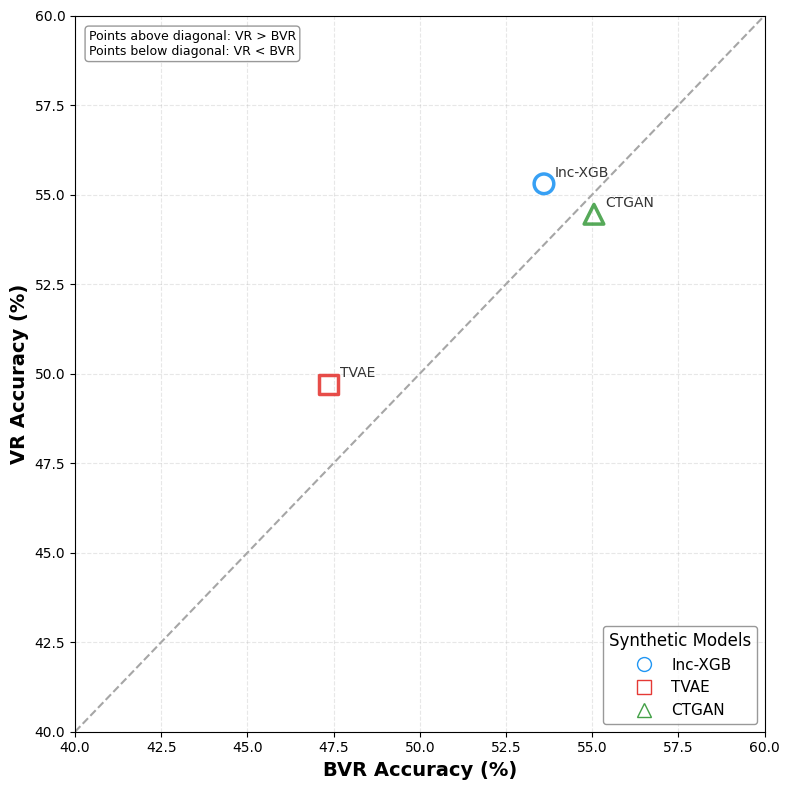


SUMMARY TABLE: Total Accuracy (%)
Model        BVR Accuracy    VR Accuracy     Difference  
------------------------------------------------------------
Inc-XGB      53.60           55.30           +1.70
TVAE         47.35           49.70           +2.35
CTGAN        55.05           54.45           -0.60


In [6]:
import os
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

username = 'donatella.papa'
input_dir = rf"G:\Users\{username}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step4\Output\Report"
output_dir = rf"G:\Users\{username}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step4\Output\Plot"
os.makedirs(output_dir, exist_ok=True)

# Colors for synthetic models - IN COLORE

model_colors = {
    'xgboost': "#2196F3",  # blu
    'tvae':    "#E53935",  # rosso
    'ctgan':   "#43A047"   # verde
}
'''
# Colors for synthetic models - in grayscale
model_colors = {
    'xgboost': "#1a1a1a",  # very dark gray
    'tvae': "#4d4d4d",     # dark gray
    'ctgan': "#8c8c8c"     # medium gray
}
'''
# Markers for synthetic models
model_markers = {
    'xgboost': 'o',      # circle
    'tvae': 's',         # square
    'ctgan': '^'         # triangle
}

# Display names for models
model_display_names = {
    'xgboost': 'Inc-XGB',
    'tvae': 'TVAE',
    'ctgan': 'CTGAN'
}

# File mapping
report_files = {
    'xgboost': 'attack2_complete_SY40_xgboost_lda_report_20260325_093857.txt',
    'tvae': 'attack2_complete_SY40_tvae_lda_report_20260323_125328.txt',
    'ctgan': 'attack2_complete_SY40_ctgan_lda_report_20260323_130027.txt'
}

def extract_accuracy(filepath, model_type):
    """Extract accuracy from report file"""
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()
        
        if model_type == 'VR':
            # Extract attack accuracy
            match = re.search(r'Attack accuracy on VR:\s*([0-9.]+)', content)
            if match:
                return float(match.group(1)) * 100  # Convert to percentage
        elif model_type == 'BVR':
            # Extract test accuracy (M2)
            match = re.search(r'Test accuracy:\s*([0-9.]+)', content)
            if match:
                return float(match.group(1)) * 100  # Convert to percentage
        
        return None
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

# Extract data from reports
data = {}
for model, filename in report_files.items():
    filepath = os.path.join(input_dir, filename)
    if os.path.exists(filepath):
        br_acc = extract_accuracy(filepath, 'BVR')
        vr_acc = extract_accuracy(filepath, 'VR')
        if br_acc is not None and vr_acc is not None:
            data[model] = {'BVR': br_acc, 'VR': vr_acc}
            print(f"{model_display_names[model]}: BVR={br_acc:.2f}%, VR={vr_acc:.2f}%")
        else:
            print(f"Warning: Could not extract data for {model}")
    else:
        print(f"File not found: {filepath}")

if not data:
    print("No data extracted. Please check file paths.")
else:
    # Create scatter plot: BVR (x-axis) vs VR (y-axis)
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot points for each model
    for model, accuracies in data.items():
        br_acc = accuracies['BVR']
        vr_acc = accuracies['VR']
        
        ax.scatter(br_acc, vr_acc, 
                  s=200, 
                  marker=model_markers[model],
                  facecolors='none', 
                  edgecolors=model_colors[model],
                  linewidths=2.5, 
                  alpha=0.9,
                  zorder=3,
                  label=model_display_names[model])
        
        # Add label next to point
        ax.annotate(model_display_names[model], 
                   xy=(br_acc, vr_acc),
                   xytext=(8, 5), 
                   textcoords='offset points',
                   fontsize=10, 
                   alpha=0.8)
    
    # Add diagonal line (y=x) for reference
    min_val = 40
    max_val = 60
    ax.plot([min_val, max_val], [min_val, max_val], 
            color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
    
    # Set axes
    ax.set_xlabel('BVR Accuracy (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('VR Accuracy (%)', fontsize=14, fontweight='bold')
    
    # Set limits
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Create legend for models (colors and markers)
    
    legend_patches = []
    for model, color in model_colors.items():
        if model in data:
            legend_patches.append(Line2D([0], [0], marker=model_markers[model], 
                                        color='w', markeredgecolor=color,
                                        markerfacecolor='none', markersize=10,
                                        linestyle='None', 
                                        label=model_display_names[model]))

    
    ax.legend(handles=legend_patches, loc='lower right', fontsize=11,
              title='Synthetic Models', title_fontsize=12, frameon=True,
              facecolor='white', edgecolor='gray')
    
    # Add text box with summary
    summary_text = "Points above diagonal: VR > BVR\nPoints below diagonal: VR < BVR"
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.02, 0.98, summary_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    
    # Save figure
    output_file = os.path.join(output_dir, "BVR_vs_VR_total_accuracy_scatterplot.jpeg")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\n✅ Figure saved to: {output_file}")
    
    plt.show()
    
    # Print summary table
    print("\n" + "="*60)
    print("SUMMARY TABLE: Total Accuracy (%)")
    print("="*60)
    print(f"{'Model':<12} {'BVR Accuracy':<15} {'VR Accuracy':<15} {'Difference':<12}")
    print("-"*60)
    for model, accuracies in data.items():
        diff = accuracies['VR'] - accuracies['BVR']
        sign = "+" if diff > 0 else ""
        print(f"{model_display_names[model]:<12} {accuracies['BVR']:<15.2f} {accuracies['VR']:<15.2f} {sign}{diff:.2f}")

LOADING PREDICTIONS FOR SYNTHETIC MODELS
Directory: G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step4\Output\Report\attack2_complete_results


SYNTHETIC MODEL: Inc-XGB

  Loading M2 (BR) for Inc-XGB...
    ✓ Per-class accuracies M2_BR: {np.int64(1): np.float64(53.093812375249506), np.int64(2): np.float64(52.94117647058824), np.int64(3): np.float64(52.56410256410257), np.int64(4): np.float64(55.9748427672956)}

  Loading VR for Inc-XGB...
    ✓ Per-class accuracies VR: {np.int64(1): np.float64(50.4725897920605), np.int64(2): np.float64(55.03875968992248), np.int64(3): np.float64(55.578512396694215), np.int64(4): np.float64(60.72186836518046)}

SYNTHETIC MODEL: TVAE

  Loading M2 (BR) for TVAE...
    ✓ Per-class accuracies M2_BR: {np.int64(1): np.float64(48.50299401197605), np.int64(2): np.float64(45.168067226890756), np.int64(3): np.float64(47.8021978021978), np.int64(4): np.float64(47.79874213836478)}

  Loading VR for TVAE...
    ✓ Per-class accuracies VR: {np.int64(

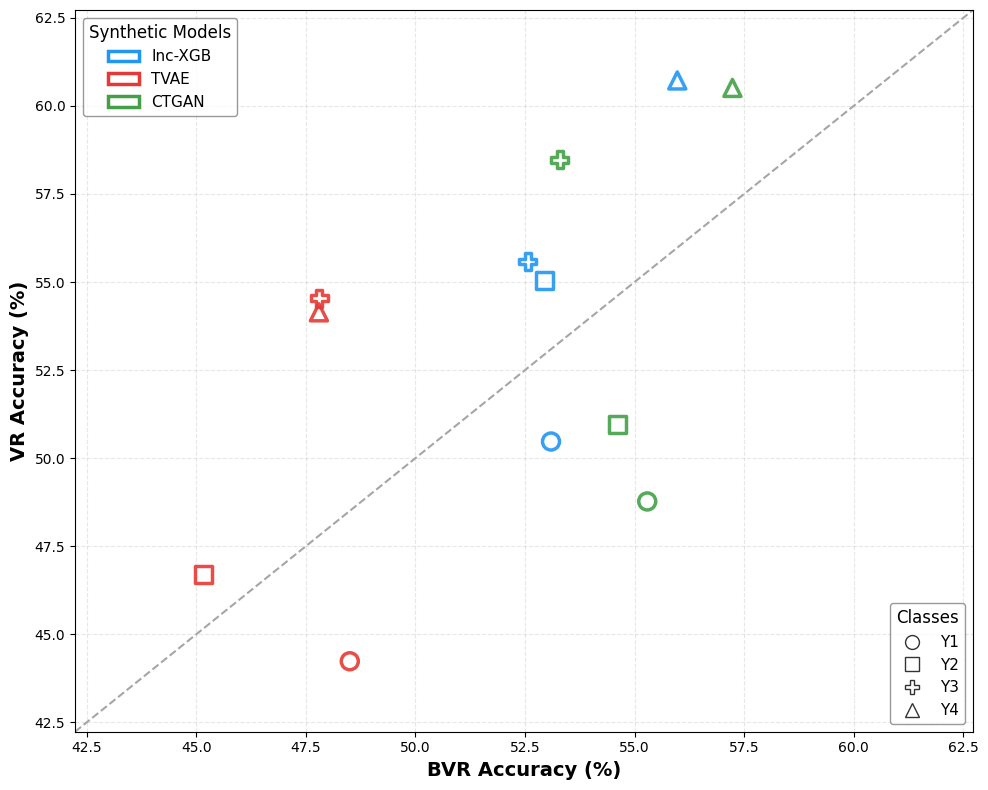


DETAILED ANALYSIS: BVR vs VR Accuracy by Class and Model

Model           Class      BVR Accuracy (%) VR Accuracy (%) Difference (VR-BVR)
-------------------------------------------------------------------------------------
Inc-XGB         Y1         53.1            50.5            -2.6           
Inc-XGB         Y2         52.9            55.0            +2.1           
Inc-XGB         Y3         52.6            55.6            +3.0           
Inc-XGB         Y4         56.0            60.7            +4.7           
TVAE            Y1         48.5            44.2            -4.3           
TVAE            Y2         45.2            46.7            +1.5           
TVAE            Y3         47.8            54.5            +6.7           
TVAE            Y4         47.8            54.1            +6.3           
CTGAN           Y1         55.3            48.8            -6.5           
CTGAN           Y2         54.6            51.0            -3.7           
CTGAN           Y3       

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import os
import json
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

# Definisci il tuo username
username = 'donatella.papa'
input_dir = rf"G:\Users\{username}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step4\Output\Report\attack2_complete_results"
output_dir = rf"G:\Users\{username}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step4\Output\Plot"
os.makedirs(output_dir, exist_ok=True)
'''
# Colors for synthetic models - in grayscale
model_colors = {
    'xgboost': "#1a1a1a",  # very dark gray
    'tvae': "#4d4d4d",     # dark gray
    'ctgan': "#8c8c8c"     # medium gray
}
'''

model_colors = {
    'xgboost': "#2196F3",  # blu
    'tvae':    "#E53935",  # rosso
    'ctgan':   "#43A047"   # verde
}

# Markers for classes (like your original marker_map)
class_markers = {
    1: "o",    # circle
    2: "s",    # square
    3: "P",    # pentagon
    4: "^"     # triangle
}

# Display names for models
model_display_names = {
    'xgboost': 'Inc-XGB',
    'tvae': 'TVAE',
    'ctgan': 'CTGAN'
}

# Define the three synthetic models
synthetic_models = ['xgboost', 'tvae', 'ctgan']

# Define the complete suffixes from your files
model_suffixes = {
    'xgboost': 'xgboost_lda_20260325_093857',
    'tvae': 'tvae_lda_20260323_125328',
    'ctgan': 'ctgan_lda_20260323_130027'
}

def load_predictions(filepath):
    """Load predictions from file"""
    try:
        if os.path.exists(f"{filepath}.csv"):
            data = pd.read_csv(f"{filepath}.csv")
            return data
        elif os.path.exists(f"{filepath}.json"):
            with open(f"{filepath}.json", 'r') as f:
                data = json.load(f)
                return pd.DataFrame(data)
        elif os.path.exists(f"{filepath}.npy"):
            data = np.load(f"{filepath}.npy")
            return pd.DataFrame(data)
        else:
            return None
    except Exception as e:
        print(f"  Error loading: {e}")
        return None

def extract_predictions(data):
    """Extract predictions from loaded data"""
    if isinstance(data, pd.DataFrame):
        for col in data.columns:
            if 'pred' in col.lower() or 'predict' in col.lower():
                return data[col].values
        for col in data.columns:
            if pd.api.types.is_numeric_dtype(data[col]):
                return data[col].values
        return data.iloc[:, 0].values
    else:
        return data

def extract_true_labels(data):
    """Extract true labels from loaded data"""
    if isinstance(data, pd.DataFrame):
        for col in data.columns:
            if 'true' in col.lower() or 'y_true' in col.lower():
                return data[col].values
    return None

def calculate_classwise_accuracy(y_true, y_pred):
    """Calculate per-class accuracy"""
    classes = np.unique(y_true)
    class_accuracies = {}
    
    for cls in classes:
        mask = (y_true == cls)
        if np.sum(mask) > 0:
            accuracy = np.sum(y_pred[mask] == cls) / np.sum(mask)
            class_accuracies[cls] = accuracy * 100  # Convert to percentage
    
    return class_accuracies

print("="*80)
print("LOADING PREDICTIONS FOR SYNTHETIC MODELS")
print("="*80)
print(f"Directory: {input_dir}\n")

# Dictionary to store all per-class accuracies
classwise_data = {}

for synth_model in synthetic_models:
    print(f"\n{'='*50}")
    print(f"SYNTHETIC MODEL: {model_display_names[synth_model]}")
    print(f"{'='*50}")
    
    suffix = model_suffixes[synth_model]
    classwise_data[synth_model] = {'VR': {}, 'M2_BR': {}}
    
    # Load M2 (BR) predictions
    print(f"\n  Loading M2 (BR) for {model_display_names[synth_model]}...")
    m2_file = f"m2_predictions_SY40_{suffix}"
    m2_path = os.path.join(input_dir, m2_file)
    m2_data = load_predictions(m2_path)
    
    if m2_data is not None:
        y_pred_m2 = extract_predictions(m2_data)
        y_true_m2 = extract_true_labels(m2_data)
        
        # If true labels not in M2 file, look in VR file
        if y_true_m2 is None:
            vr_file = f"vr_predictions_SY40_{suffix}"
            vr_path = os.path.join(input_dir, vr_file)
            vr_data = load_predictions(vr_path)
            if vr_data is not None:
                y_true_m2 = extract_true_labels(vr_data)
        
        if y_true_m2 is not None:
            class_acc = calculate_classwise_accuracy(y_true_m2, y_pred_m2)
            classwise_data[synth_model]['M2_BR'] = class_acc
            print(f"    ✓ Per-class accuracies M2_BR: {class_acc}")
        else:
            print(f"    ✗ True labels not found for M2_BR")
    
    # Load VR predictions
    print(f"\n  Loading VR for {model_display_names[synth_model]}...")
    vr_file = f"vr_predictions_SY40_{suffix}"
    vr_path = os.path.join(input_dir, vr_file)
    vr_data = load_predictions(vr_path)
    
    if vr_data is not None:
        y_pred_vr = extract_predictions(vr_data)
        y_true_vr = extract_true_labels(vr_data)
        
        # If true labels not in VR file, look in M2 file
        if y_true_vr is None:
            m2_file = f"m2_predictions_SY40_{suffix}"
            m2_path = os.path.join(input_dir, m2_file)
            m2_data = load_predictions(m2_path)
            if m2_data is not None:
                y_true_vr = extract_true_labels(m2_data)
        
        if y_true_vr is not None:
            class_acc = calculate_classwise_accuracy(y_true_vr, y_pred_vr)
            classwise_data[synth_model]['VR'] = class_acc
            print(f"    ✓ Per-class accuracies VR: {class_acc}")
        else:
            print(f"    ✗ True labels not found for VR")

# Create scatter plot: BR (x-axis) vs VR (y-axis)
fig, ax = plt.subplots(figsize=(10, 8))

# Collect all points
all_br_accuracies = []
all_vr_accuracies = []

# Plot for each synthetic model and each class
for synth_model in synthetic_models:
    m2_accuracies = classwise_data[synth_model]['M2_BR']
    vr_accuracies = classwise_data[synth_model]['VR']
    
    for cls in m2_accuracies.keys():
        if cls in vr_accuracies:
            br_acc = m2_accuracies[cls]
            vr_acc = vr_accuracies[cls]
            
            # Store for axis limits
            all_br_accuracies.append(br_acc)
            all_vr_accuracies.append(vr_acc)
            
            # Plot point with model color and class marker
            ax.scatter(br_acc, vr_acc, 
                      s=150, 
                      marker=class_markers[cls],
                      facecolors='none', 
                      edgecolors=model_colors[synth_model],
                      linewidths=2.5, 
                      alpha=0.9,
                      zorder=3)

# Add diagonal line (y=x) for reference
min_val = min(min(all_br_accuracies), min(all_vr_accuracies)) - 2
max_val = max(max(all_br_accuracies), max(all_vr_accuracies)) + 2
ax.plot([min_val, max_val], [min_val, max_val], 
        color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)

# Set axes
ax.set_xlabel('BVR Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('VR Accuracy (%)', fontsize=14, fontweight='bold')

# Set limits
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# Add grid
ax.grid(True, linestyle='--', alpha=0.3)

# Create legend for models (colors)
model_patches = [mpatches.Patch(facecolor='none', edgecolor=color, 
                                linewidth=2.5, label=model_display_names[model]) 
                 for model, color in model_colors.items()]

# Create legend for classes (markers)
'''
class_legend = [Line2D([0], [0], marker=marker, color='gray', 
                       markeredgecolor='w', markerfacecolor='none',
                       markersize=10, linestyle='None', 
                       label=f'Y{cls}') 
                for cls, marker in class_markers.items()]
'''
class_legend = [Line2D([0], [0], marker=marker, color='w', 
                       markeredgecolor='#333333', markerfacecolor='none',
                       markersize=10, linestyle='None', 
                       label=f'Y{cls}') 
                for cls, marker in class_markers.items()]

# Combine legends
first_legend = ax.legend(handles=model_patches, loc='upper left', fontsize=11, 
                         title='Synthetic Models', title_fontsize=12, frameon=True,
                         facecolor='white', edgecolor='gray')

# Add second legend
ax.add_artist(first_legend)
ax.legend(handles=class_legend, loc='lower right', fontsize=11,
          title='Classes', title_fontsize=12, frameon=True,
          facecolor='white', edgecolor='gray')

plt.tight_layout()

# Save figure
output_file = os.path.join(output_dir, "BVR_vs_VR_scatterplot_model_colors_class_markers.jpeg")
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✅ Figure saved to: {output_file}")

plt.show()

# Print detailed analysis
print("\n" + "="*100)
print("DETAILED ANALYSIS: BVR vs VR Accuracy by Class and Model")
print("="*100)

# Create a table for easier comparison
print("\n{:<15} {:<10} {:<15} {:<15} {:<15}".format("Model", "Class", "BVR Accuracy (%)", "VR Accuracy (%)", "Difference (VR-BVR)"))
print("-"*85)

for synth_model in synthetic_models:
    m2_accuracies = classwise_data[synth_model]['M2_BR']
    vr_accuracies = classwise_data[synth_model]['VR']
    
    for cls in sorted(m2_accuracies.keys()):
        if cls in vr_accuracies:
            br_acc = m2_accuracies[cls]
            vr_acc = vr_accuracies[cls]
            diff = vr_acc - br_acc
            print("{:<15} {:<10} {:<15.1f} {:<15.1f} {:<+15.1f}".format(
                model_display_names[synth_model], f'Y{cls}', br_acc, vr_acc, diff))

# Calculate and print average differences
print("\n" + "="*100)
print("AVERAGE DIFFERENCES (VR - BVR) by Model")
print("="*100)

for synth_model in synthetic_models:
    m2_accuracies = classwise_data[synth_model]['M2_BR']
    vr_accuracies = classwise_data[synth_model]['VR']
    
    diffs = []
    for cls in m2_accuracies.keys():
        if cls in vr_accuracies:
            diffs.append(vr_accuracies[cls] - m2_accuracies[cls])
    
    if diffs:
        avg_diff = np.mean(diffs)
        print(f"{model_display_names[synth_model]}: {avg_diff:+.2f}%")

# Calculate and print average differences by class
print("\n" + "="*100)
print("AVERAGE DIFFERENCES (VR - BVR) by Class")
print("="*100)

all_classes = set()
for synth_model in synthetic_models:
    all_classes.update(classwise_data[synth_model]['M2_BR'].keys())
    all_classes.update(classwise_data[synth_model]['VR'].keys())

for cls in sorted(all_classes):
    diffs = []
    for synth_model in synthetic_models:
        m2_acc = classwise_data[synth_model]['M2_BR'].get(cls, None)
        vr_acc = classwise_data[synth_model]['VR'].get(cls, None)
        if m2_acc is not None and vr_acc is not None:
            diffs.append(vr_acc - m2_acc)
    
    if diffs:
        avg_diff = np.mean(diffs)
        print(f"Y{cls}: {avg_diff:+.2f}%")